## Imports

In [1]:
# Base libraries
import pandas as pd
import numpy as np
from ast import literal_eval
import os
import matplotlib.pyplot as plt
import pyprind
from collections import Counter, defaultdict
from win11toast import notify
import scipy
import pickle

# for the regular LCA functions :
import brightway2 as bw

# for the regular performance assessment functions : 
import pelicun
from pelicun.base import Options, convert_to_MultiIndex
from pelicun.assessment import Assessment


import database_wide_monte_carlo as dbmc
import presamples as ps

# for the cross-over functions : 
import pelicun_2_bw2 as p2b

## Function imports

In [2]:
def get_C_matrices(demand, list_of_methods):
    """ Return a dict with {method tuple:cf_matrix} for a list of methods
    Uses a "sacrificial LCA" with exactly the same demand as will be used
    in the MonteCarloLCA
    """
    C_matrices = {}
    sacrificial_LCA = bw.LCA(demand)
    sacrificial_LCA.lci()
    for method in list_of_methods:
        sacrificial_LCA.switch_method(method)
        C_matrices[method] = sacrificial_LCA.characterization_matrix
    return C_matrices

def convert_act_to_score_S(act_UP, db_S, list_methods):
    """
    Create a database storing cumulative LCIA scores of specified LCIA methods for unit processes (UP).  
    """
    # Make sure activity and methods exist
    assert isinstance(list_methods, list), "Methods should be a list of methods"
    for m in list_methods:
        assert m in bw.methods, "{} is not a recognized method name"
    assert "Activity" in str(type(act_UP))
    # Create a new database for S datasets if one doesn't already exist
    if db_S not in bw.databases:
        bw.Database(db_S).register()
        
    # Make sure act_UP does not already exist in the S database : 
    try : 
        # Create a copy of the UP activity in the S database
        act_S = act_UP.copy(database=db_S, code=act_UP.key[1])
    except : 
        # If the dataset already exists : 
        act_S = bw.Database(db_S).get(act_UP.key[1])
    # Remove all exchanges except the production exchange
    for exc in act_S.technosphere():
        exc.delete()
    for exc in act_S.biosphere():
        exc.delete()
    # Create an LCA object to calculate LCIA scores
    lca = bw.LCA({act_UP:1})
    lca.lci()
    # Add LCIA scores for each method
    # The elementary flow key is ('biosphere3', method_abbreviation)
    for m in list_methods:
        new_exc = act_S.new_exchange()
        new_exc['input'] = ('biosphere3',
                            bw.Method(m).get_abbreviation()
                           )
        new_exc['output'] = act_S.key
        lca.switch_method(m)
        lca.lcia()
        new_exc['amount'] = lca.score
        new_exc['type'] = 'biosphere'
        new_exc.save()
    # Save the activity
    act_S.save()
        
    #cursor.close()
    return act_S

def fix_missing_uncertainty_type_field(project_name, database_name):
    """
    In running MC simulations with water/land balancers, the uncertainty type is required. 
    GUI such as the Activity-browser currently neglects adding this information to new exchanges.
    """
    log = [] # log modified datasets/exchanges 
    
    # Ensure to work in the appropriate project
    bw.projects.set_current(project_name)
    
    # Search the database for the missing exchange field 
    for ds in bw.Database(database_name) : 
        for exc in ds.exchanges() : 
            try : 
                exc['uncertainty type']
            except : 
                log.append((ds['name'],exc.input['name']))
                exc['uncertainty type'] = 0 # Undefined or unknown
                exc.save()
                
    if len(log)!=0 : 
        print(f'Updated {len(log)} exchanges in database {database_name}.')
    else : 
        print('No dataset to update.')
                            
    return log

def trace_dependent_db(database_name) : 
    """
    Iterate through a database to identify all possible database dependencies
    
    ## Note : if dependencies are not up to date, run a sacrificial LCA first (force update)
    
    """
    
    # Make a shallow copy from the 1st layer of dependent databases 
    master_list = list(bw.Database(database_name).metadata['depends'])
    
    # Initiate storage variables
    updated_depends = []
    
    # Initial differences :  
    diff_depends = len(master_list)-len(updated_depends)
    
    # Check all list elements for their own dependent databases :    
    while diff_depends > 0 : 
        
        # Shallow copy of the up to date master list : 
        updated_depends = list(master_list) 
        
        for db in master_list : 
            # Find closest dependents
            dependent_db = bw.Database(db).metadata['depends']
            
            # Add to the copy of the master list
            updated_depends.extend(dependent_db)

            # Clear duplicates
        updated_depends = list(set(updated_depends)) # Clear databases flagged already
        
        # Check if this iteration yields any change : 
        diff_depends = len([x for x in updated_depends if x not in master_list])
    
        master_list = updated_depends
        
    return master_list

def col_IDs_to_names(database_name,biosphere = 'biosphere3') : 
    """
    Inputs:
    database_name : the name of the database which was used to generate LCA results (database of the reference flow)
    
    Outputs:
    Yields a dictionnary of Activity IDs as keys and legible Activity names as values. 
    """
 
    
    # Find dependents 
    dependents = trace_dependent_db(database_name)
    # Remove the biosphere from the list (not activities per say)
    dependents = [db for db in dependents if db != 'biosphere3']
    
    # Generate a sacrificial LCA to build indices : 
    sacrificial_LCA = bw.LCA({bw.Database(database_name).random():1})
    sacrificial_LCA.lci()
    
    
    # Map Activities : 
    #--------------------------------------------------------------------
    # Initiate a storage variable
    all_unique_activities_and_their_keys = defaultdict(list)
    
    # Start iterating to link datasets with IDs : 
    for db in dependents :
        for activity in bw.Database(db) : 
            if activity.key in sacrificial_LCA.activity_dict:
                all_unique_activities_and_their_keys[f"{activity['reference product']},{activity['name']},{activity['location']}"].append(activity.key)
        
    # get a dictionnary of the IDs for all activities: 
    all_unique_columns_and_their_activities = {
        sacrificial_LCA.activity_dict[key[0]] : name 
        for name,key in all_unique_activities_and_their_keys.items()   
    }
        
    return(all_unique_columns_and_their_activities)


def standardize_technosphere(mc_ps) : 
    """
    Disaggregation functions    
    """
    
    # Find total demand for aggregated datasets
    row_sums = mc_ps.technosphere_matrix.sum(axis=1)*(-1) # include a sign flip 
    # Row sums = 0 indicate the dataset is only an intermediate one (+1 on diagonal, -1 when consummed by another = 0)
    #reduced_sums = row_sums[np.nonzero(row_sums)]
    # Use the A/B LCA matrix format to isolate only the preaggregated datasets :
    reduced_sums = row_sums[np.nonzero(mc_ps.biosphere_matrix.sum(axis=0))[1]].T
    
    # Row sums = -1 indicate a non-triggered damage (+1 accounts for technosphere format of "1" as activity output) 
    filtered_sums = reduced_sums[:,np.where(reduced_sums!=-1)[1]]+1

    # Reduce the technosphere to match the row size of reduced_sum
    reduced_results = mc_ps.technosphere_matrix[np.nonzero(mc_ps.biosphere_matrix.sum(axis=0))[1],:]
    
    # Match the filtered sums row size
    filtered_results = reduced_results[np.where(reduced_sums!=-1)[1],:]

    # Standardize results relative to the total sum :
    sums_CSR_format = scipy.sparse.diags(1/filtered_sums.A.ravel())*(-1)
    standardized_technosphere = (sums_CSR_format @ filtered_results)

    # Remove production quantity columns
    standardized_technosphere.data[np.where(standardized_technosphere.data < 0)] = 0
    standardized_technosphere.eliminate_zeros()
    return standardized_technosphere

def deaggregate_results(standardized_technosphere, a_score) : 
    # Disaggregate results according to component ID
    deaggregated_results = (a_score @ standardized_technosphere)
    
    return deaggregated_results

def technosphere_col_IDs_to_act_name(LCA_obj,dependents):
    # Map Activities : 
    #--------------------------------------------------------------------
    # Initiate a storage variable
    all_unique_activities_and_their_keys = defaultdict(list)

    # Start iterating to link datasets with IDs : 
    for db in dependents :
        for activity in bw.Database(db) : 
            if activity.key in LCA_obj.activity_dict:
                all_unique_activities_and_their_keys[(f"{activity['reference product']}")].append(activity.key)

    # get the columns for all elementary processes : 
    all_unique_columns_and_their_activities = {
        LCA_obj.activity_dict[key[0]] : name 
        for name,key in all_unique_activities_and_their_keys.items() 
    }    
 
    return all_unique_columns_and_their_activities

## Initial parameters

In [3]:
sample_size = 12000 # Number of damage simulations 
delta_y = 0.0075 # What should be the drift limit to trigger replacement

### Initialize a pelicun assessment and trigger access to resources

In [4]:
PAL = Assessment({"PrintLog": True, "Seed": 410,})

pelicun 3.2b2 | 

System Information:
         local time zone: Est
         start time: 2026-02-16T09:33:01
         python: 3.11.4 | packaged by conda-forge | (main, Jun 10 2023, 17:59:51) [MSC v.1935 64 bit (AMD64)]
         numpy: 1.25.2
         pandas: 2.0.0
         
         --------------------------------------------------------------------------------
09:33:01 Assessement Started


## Imports

### Assessment summary


* The building in this assessment is a 19 story building, subjected to hurricane winds
      
      ** PID : Peak interstory drift
      ** PFA : Peak floor acceleration 
      
* loc refers to the story 
* dir refers to the direction (x or y direction in the building)

### EDP inputs

In [5]:
MRI_dem_dict = {}

# prepare demand input
raw_demands = convert_to_MultiIndex(pd.read_excel('building_EDPs.xlsx', index_col=0), axis=0)
ls_MRIs =  sorted([MRI for MRI in raw_demands.index.levels[0]],key = int)

for MRI in ls_MRIs : 
    # prepare the demand input for pelicun    
    MRI_demands = raw_demands.loc[MRI,:]  
    MRI_demands = MRI_demands.sort_index() #avoid lexsort performance warnings
    MRI_demands.loc[('PFA',0,0),:]=(0,0)  # Since this is a wind event, the ground level is deemed fixed.     
    MRI_demands = MRI_demands.sort_index()    
    # units - - - - - - - - - - - - - - - - - - - - - - - -  
    MRI_demands.insert(0, 'Units',"")
    MRI_demands.loc['PFA','Units'] = 'g'
    MRI_demands.loc['PID','Units'] = 'rad'
    MRI_demands.loc['PFD','Units'] = 'm'
    
    # distribution family  - - - - - - - - - - - - - - - - -  
    MRI_demands.insert(1, 'Family',"")
    MRI_demands['Family'] = 'lognormal'    
    MRI_demands.loc[('PFA',0,0),'Family'] = 'deterministic' # Since this is a wind event, no uncertainty there.
    
    # distribution parameters  - - - - - - - - - - - - - - -
    MRI_demands.rename(columns = {'median': 'Theta_0'}, inplace=True)
    MRI_demands.rename(columns = {'std_log': 'Theta_1'}, inplace=True)    
    
    MRI_dem_dict[MRI] = MRI_demands
    
display_MRI_EDP = True
if display_MRI_EDP == True : 
    for MRI in MRI_dem_dict.keys() : 
        display(MRI_dem_dict[MRI])

Units     Family   Theta_0   Theta_1
PFA 1  1     g  lognormal  0.002810  0.332405
    10 1     g  lognormal  0.007032  0.292697
    11 1     g  lognormal  0.007206  0.290332
    12 1     g  lognormal  0.007394  0.288888
    13 1     g  lognormal  0.007730  0.286358
...        ...        ...       ...       ...
PID 5  1   rad  lognormal  0.000505  0.110067
    6  1   rad  lognormal  0.000509  0.110862
    7  1   rad  lognormal  0.000507  0.111600
    8  1   rad  lognormal  0.000505  0.113137
    9  1   rad  lognormal  0.000502  0.115662

[58 rows x 4 columns]

Units     Family   Theta_0   Theta_1
PFA 1  1     g  lognormal  0.003603  0.343109
    10 1     g  lognormal  0.009362  0.297909
    11 1     g  lognormal  0.009622  0.294059
    12 1     g  lognormal  0.009845  0.291670
    13 1     g  lognormal  0.010274  0.286305
...        ...        ...       ...       ...
PID 5  1   rad  lognormal  0.000696  0.097970
    6  1   rad  lognormal  0.000702  0.098941
    7  1   rad  lognormal  0.000699  0.100085
    8  1   rad  lognormal  0.000698  0.101880
    9  1   rad  lognormal  0.000694  0.104683

[58 rows x 4 columns]

Units     Family   Theta_0   Theta_1
PFA 1  1     g  lognormal  0.004887  0.329768
    10 1     g  lognormal  0.012412  0.271526
    11 1     g  lognormal  0.012666  0.265351
    12 1     g  lognormal  0.013102  0.260689
    13 1     g  lognormal  0.013765  0.256198
...        ...        ...       ...       ...
PID 5  1   rad  lognormal  0.000928  0.096841
    6  1   rad  lognormal  0.000936  0.097426
    7  1   rad  lognormal  0.000932  0.098120
    8  1   rad  lognormal  0.000929  0.099402
    9  1   rad  lognormal  0.000924  0.101114

[58 rows x 4 columns]

Units     Family   Theta_0   Theta_1
PFA 1  1     g  lognormal  0.006183  0.304837
    10 1     g  lognormal  0.016006  0.246969
    11 1     g  lognormal  0.016348  0.239891
    12 1     g  lognormal  0.016774  0.234894
    13 1     g  lognormal  0.017590  0.230550
...        ...        ...       ...       ...
PID 5  1   rad  lognormal  0.001207  0.089055
    6  1   rad  lognormal  0.001216  0.089747
    7  1   rad  lognormal  0.001212  0.090711
    8  1   rad  lognormal  0.001211  0.092203
    9  1   rad  lognormal  0.001205  0.094318

[58 rows x 4 columns]

Units     Family   Theta_0   Theta_1
PFA 1  1     g  lognormal  0.008139  0.286321
    10 1     g  lognormal  0.020485  0.235189
    11 1     g  lognormal  0.020951  0.229896
    12 1     g  lognormal  0.021265  0.223700
    13 1     g  lognormal  0.022087  0.216632
...        ...        ...       ...       ...
PID 5  1   rad  lognormal  0.001506  0.089842
    6  1   rad  lognormal  0.001520  0.090597
    7  1   rad  lognormal  0.001516  0.091462
    8  1   rad  lognormal  0.001515  0.092553
    9  1   rad  lognormal  0.001504  0.093976

[58 rows x 4 columns]

...

Units     Family   Theta_0   Theta_1
PFA 1  1     g  lognormal  0.031671  0.259179
    10 1     g  lognormal  0.071133  0.149572
    11 1     g  lognormal  0.075989  0.145847
    12 1     g  lognormal  0.080511  0.144765
    13 1     g  lognormal  0.085933  0.143565
...        ...        ...       ...       ...
PID 5  1   rad  lognormal  0.004769  0.125337
    6  1   rad  lognormal  0.004830  0.133225
    7  1   rad  lognormal  0.004845  0.129769
    8  1   rad  lognormal  0.004869  0.119911
    9  1   rad  lognormal  0.004843  0.118565

[58 rows x 4 columns]

Units     Family   Theta_0   Theta_1
PFA 1  1     g  lognormal  0.040892  0.239306
    10 1     g  lognormal  0.086141  0.127195
    11 1     g  lognormal  0.091977  0.122461
    12 1     g  lognormal  0.096205  0.118074
    13 1     g  lognormal  0.104191  0.113007
...        ...        ...       ...       ...
PID 5  1   rad  lognormal  0.006287  0.260900
    6  1   rad  lognormal  0.006323  0.270137
    7  1   rad  lognormal  0.006189  0.264795
    8  1   rad  lognormal  0.006148  0.243129
    9  1   rad  lognormal  0.005961  0.232599

[58 rows x 4 columns]

Units     Family   Theta_0   Theta_1
PFA 1  1     g  lognormal  0.058321  0.221956
    10 1     g  lognormal  0.105608  0.110842
    11 1     g  lognormal  0.113672  0.107606
    12 1     g  lognormal  0.114551  0.108497
    13 1     g  lognormal  0.126116  0.101941
...        ...        ...       ...       ...
PID 5  1   rad  lognormal  0.011864  0.389937
    6  1   rad  lognormal  0.011945  0.396484
    7  1   rad  lognormal  0.011674  0.395524
    8  1   rad  lognormal  0.010920  0.381725
    9  1   rad  lognormal  0.009928  0.379279

[58 rows x 4 columns]

Units     Family   Theta_0   Theta_1
PFA 1  1     g  lognormal  0.071998  0.231010
    10 1     g  lognormal  0.115596  0.107571
    11 1     g  lognormal  0.125365  0.104777
    12 1     g  lognormal  0.124147  0.103087
    13 1     g  lognormal  0.139292  0.105204
...        ...        ...       ...       ...
PID 5  1   rad  lognormal  0.019699  0.388529
    6  1   rad  lognormal  0.019305  0.393269
    7  1   rad  lognormal  0.018486  0.399345
    8  1   rad  lognormal  0.017095  0.399605
    9  1   rad  lognormal  0.015940  0.413731

[58 rows x 4 columns]

Units     Family   Theta_0   Theta_1
PFA 1  1     g  lognormal  0.072780  0.213954
    10 1     g  lognormal  0.116971  0.095872
    11 1     g  lognormal  0.125915  0.100422
    12 1     g  lognormal  0.132404  0.099325
    13 1     g  lognormal  0.141672  0.099044
...        ...        ...       ...       ...
PID 5  1   rad  lognormal  0.022550  0.339224
    6  1   rad  lognormal  0.022693  0.352728
    7  1   rad  lognormal  0.021973  0.364736
    8  1   rad  lognormal  0.019845  0.373508
    9  1   rad  lognormal  0.018430  0.393435

[58 rows x 4 columns]

In [6]:
# Add correlations between EDP samples

demand_correlations = {}

for MRI in ls_MRIs : 
    df = convert_to_MultiIndex(pd.read_excel('building_EDPs_correlations.xlsx', index_col = 0))
    
    # Small edit : a deterministic PFA at floor 0 is introduced in demands, thus the correlations should be updated : 
    df.loc[('PFA',0,0)] = 0
    df[("PFA-0-0")] = 0    
    df = convert_to_MultiIndex(df,axis = 1).sort_index(axis =1).sort_index(axis=0)   
    df.loc[('PFA',0,0),('PFA','0','0')] = 1
    demand_correlations[MRI] = df 

if display_MRI_EDP == True :
    for MRI in ls_MRIs : 
        display(demand_correlations[MRI])

PFA                                                                                                                                                                                                     PFD                                                                                   
           0         1        10        11        12        13        14        15        16        17        18        19         2         3         4         5         6         7         8         9         1        10        11        12        13        14        15        16        17   
           0         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1   
PFA 0  0   1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  \
    1  1   0  1.000000  0.861287  0.821475  0.799895  0.818007  0.774381  0.787500  0.835423  0.819430  0.844342  0.916494  0.996497  0.986379  0.973463  0.961239  0.947068  0.929443  0.898003  0.876340  0.374366  0.388931  0.389756  0.391499  0.397166  0.404895  0.414376  0.425164  0.439461   
    10 1   0  0.861287  1.000000  0.992805  0.981242  0.975758  0.956934  0.940968  0.951189  0.963895  0.976162  0.962266  0.873884  0.888263  0.905647  0.927312  0.949453  0.967134  0.981594  0.994672  0.397968  0.435224  0.439742  0.446099  0.456220  0.469241  0.484415  0.501139  0.523016   
    11 1   0  0.821475  0.992805  1.000000  0.993992  0.982901  0.973825  0.956727  0.960860  0.977237  0.981806  0.951668  0.834635  0.849897  0.868794  0.893104  0.919800  0.943657  0.965541  0.983725  0.395503  0.438031  0.443463  0.450877  0.461987  0.476086  0.492260  0.509848  0.532815   
    12 1   0  0.799895  0.981242  0.993992  1.000000  0.990853  0.986668  0.970500  0.967169  0.982528  0.978724  0.939275  0.812034  0.825726  0.843495  0.868561  0.898148  0.925590  0.950575  0.969802  0.392120  0.438644  0.444709  0.452740  0.464346  0.479009  0.495657  0.513558  0.536901   
...       ..       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...   
PID 5  1   0  0.394574  0.441019  0.443170  0.443099  0.445702  0.441870  0.445947  0.451597  0.455658  0.449864  0.430454  0.397164  0.397882  0.401242  0.407972  0.415962  0.423079  0.432371  0.435195  0.978537  0.999270  0.998208  0.995906  0.992469  0.987226  0.979555  0.970487  0.958146   
    6  1   0  0.394053  0.446593  0.450087  0.451153  0.453225  0.450428  0.454283  0.458314  0.462995  0.456489  0.434873  0.396775  0.397652  0.401518  0.409336  0.418394  0.426616  0.437264  0.440619  0.968019  0.998237  0.998929  0.998427  0.996626  0.992970  0.986879  0.979091  0.967887   
    7  1   0  0.393331  0.453562  0.458814  0.460899  0.462181  0.460513  0.463781  0.466472  0.472171  0.465235  0.440760  0.396200  0.397263  0.401739  0.410765  0.421050  0.430705  0.443013  0.447303  0.954886  0.993719  0.996270  0.997918  0.998203  0.996624  0.992656  0.986624  0.977081   
    8  1   0  0.397012  0.467405  0.474760  0.477842  0.478126  0.477885  0.480222  0.482305  0.488946  0.481229  0.452976  0.400054  0.401453  0.406847  0.417414  0.429084  0.440305  0.454584  0.460533  0.937758  0.984496  0.988936  0.992953  0.995892  0.997237  0.996410  0.993028  0.986188   
    9  1   0  0.408784  0.488717  0.497709  0.501485  0.500842  0.501792  0.503826  0.506003  0.512975  0.504778  0.473345  0.412170  0.414124  0.420558  0.43250

PFA                                                                                                                                                                                                     PFD                                                                                   
           0         1        10        11        12        13        14        15        16        17        18        19         2         3         4         5         6         7         8         9         1        10        11        12        13        14        15        16        17   
           0         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1   
PFA 0  0   1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  \
    1  1   0  1.000000  0.861287  0.821475  0.799895  0.818007  0.774381  0.787500  0.835423  0.819430  0.844342  0.916494  0.996497  0.986379  0.973463  0.961239  0.947068  0.929443  0.898003  0.876340  0.374366  0.388931  0.389756  0.391499  0.397166  0.404895  0.414376  0.425164  0.439461   
    10 1   0  0.861287  1.000000  0.992805  0.981242  0.975758  0.956934  0.940968  0.951189  0.963895  0.976162  0.962266  0.873884  0.888263  0.905647  0.927312  0.949453  0.967134  0.981594  0.994672  0.397968  0.435224  0.439742  0.446099  0.456220  0.469241  0.484415  0.501139  0.523016   
    11 1   0  0.821475  0.992805  1.000000  0.993992  0.982901  0.973825  0.956727  0.960860  0.977237  0.981806  0.951668  0.834635  0.849897  0.868794  0.893104  0.919800  0.943657  0.965541  0.983725  0.395503  0.438031  0.443463  0.450877  0.461987  0.476086  0.492260  0.509848  0.532815   
    12 1   0  0.799895  0.981242  0.993992  1.000000  0.990853  0.986668  0.970500  0.967169  0.982528  0.978724  0.939275  0.812034  0.825726  0.843495  0.868561  0.898148  0.925590  0.950575  0.969802  0.392120  0.438644  0.444709  0.452740  0.464346  0.479009  0.495657  0.513558  0.536901   
...       ..       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...   
PID 5  1   0  0.394574  0.441019  0.443170  0.443099  0.445702  0.441870  0.445947  0.451597  0.455658  0.449864  0.430454  0.397164  0.397882  0.401242  0.407972  0.415962  0.423079  0.432371  0.435195  0.978537  0.999270  0.998208  0.995906  0.992469  0.987226  0.979555  0.970487  0.958146   
    6  1   0  0.394053  0.446593  0.450087  0.451153  0.453225  0.450428  0.454283  0.458314  0.462995  0.456489  0.434873  0.396775  0.397652  0.401518  0.409336  0.418394  0.426616  0.437264  0.440619  0.968019  0.998237  0.998929  0.998427  0.996626  0.992970  0.986879  0.979091  0.967887   
    7  1   0  0.393331  0.453562  0.458814  0.460899  0.462181  0.460513  0.463781  0.466472  0.472171  0.465235  0.440760  0.396200  0.397263  0.401739  0.410765  0.421050  0.430705  0.443013  0.447303  0.954886  0.993719  0.996270  0.997918  0.998203  0.996624  0.992656  0.986624  0.977081   
    8  1   0  0.397012  0.467405  0.474760  0.477842  0.478126  0.477885  0.480222  0.482305  0.488946  0.481229  0.452976  0.400054  0.401453  0.406847  0.417414  0.429084  0.440305  0.454584  0.460533  0.937758  0.984496  0.988936  0.992953  0.995892  0.997237  0.996410  0.993028  0.986188   
    9  1   0  0.408784  0.488717  0.497709  0.501485  0.500842  0.501792  0.503826  0.506003  0.512975  0.504778  0.473345  0.412170  0.414124  0.420558  0.43250

PFA                                                                                                                                                                                                     PFD                                                                                   
           0         1        10        11        12        13        14        15        16        17        18        19         2         3         4         5         6         7         8         9         1        10        11        12        13        14        15        16        17   
           0         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1   
PFA 0  0   1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  \
    1  1   0  1.000000  0.861287  0.821475  0.799895  0.818007  0.774381  0.787500  0.835423  0.819430  0.844342  0.916494  0.996497  0.986379  0.973463  0.961239  0.947068  0.929443  0.898003  0.876340  0.374366  0.388931  0.389756  0.391499  0.397166  0.404895  0.414376  0.425164  0.439461   
    10 1   0  0.861287  1.000000  0.992805  0.981242  0.975758  0.956934  0.940968  0.951189  0.963895  0.976162  0.962266  0.873884  0.888263  0.905647  0.927312  0.949453  0.967134  0.981594  0.994672  0.397968  0.435224  0.439742  0.446099  0.456220  0.469241  0.484415  0.501139  0.523016   
    11 1   0  0.821475  0.992805  1.000000  0.993992  0.982901  0.973825  0.956727  0.960860  0.977237  0.981806  0.951668  0.834635  0.849897  0.868794  0.893104  0.919800  0.943657  0.965541  0.983725  0.395503  0.438031  0.443463  0.450877  0.461987  0.476086  0.492260  0.509848  0.532815   
    12 1   0  0.799895  0.981242  0.993992  1.000000  0.990853  0.986668  0.970500  0.967169  0.982528  0.978724  0.939275  0.812034  0.825726  0.843495  0.868561  0.898148  0.925590  0.950575  0.969802  0.392120  0.438644  0.444709  0.452740  0.464346  0.479009  0.495657  0.513558  0.536901   
...       ..       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...   
PID 5  1   0  0.394574  0.441019  0.443170  0.443099  0.445702  0.441870  0.445947  0.451597  0.455658  0.449864  0.430454  0.397164  0.397882  0.401242  0.407972  0.415962  0.423079  0.432371  0.435195  0.978537  0.999270  0.998208  0.995906  0.992469  0.987226  0.979555  0.970487  0.958146   
    6  1   0  0.394053  0.446593  0.450087  0.451153  0.453225  0.450428  0.454283  0.458314  0.462995  0.456489  0.434873  0.396775  0.397652  0.401518  0.409336  0.418394  0.426616  0.437264  0.440619  0.968019  0.998237  0.998929  0.998427  0.996626  0.992970  0.986879  0.979091  0.967887   
    7  1   0  0.393331  0.453562  0.458814  0.460899  0.462181  0.460513  0.463781  0.466472  0.472171  0.465235  0.440760  0.396200  0.397263  0.401739  0.410765  0.421050  0.430705  0.443013  0.447303  0.954886  0.993719  0.996270  0.997918  0.998203  0.996624  0.992656  0.986624  0.977081   
    8  1   0  0.397012  0.467405  0.474760  0.477842  0.478126  0.477885  0.480222  0.482305  0.488946  0.481229  0.452976  0.400054  0.401453  0.406847  0.417414  0.429084  0.440305  0.454584  0.460533  0.937758  0.984496  0.988936  0.992953  0.995892  0.997237  0.996410  0.993028  0.986188   
    9  1   0  0.408784  0.488717  0.497709  0.501485  0.500842  0.501792  0.503826  0.506003  0.512975  0.504778  0.473345  0.412170  0.414124  0.420558  0.43250

PFA                                                                                                                                                                                                     PFD                                                                                   
           0         1        10        11        12        13        14        15        16        17        18        19         2         3         4         5         6         7         8         9         1        10        11        12        13        14        15        16        17   
           0         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1   
PFA 0  0   1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  \
    1  1   0  1.000000  0.861287  0.821475  0.799895  0.818007  0.774381  0.787500  0.835423  0.819430  0.844342  0.916494  0.996497  0.986379  0.973463  0.961239  0.947068  0.929443  0.898003  0.876340  0.374366  0.388931  0.389756  0.391499  0.397166  0.404895  0.414376  0.425164  0.439461   
    10 1   0  0.861287  1.000000  0.992805  0.981242  0.975758  0.956934  0.940968  0.951189  0.963895  0.976162  0.962266  0.873884  0.888263  0.905647  0.927312  0.949453  0.967134  0.981594  0.994672  0.397968  0.435224  0.439742  0.446099  0.456220  0.469241  0.484415  0.501139  0.523016   
    11 1   0  0.821475  0.992805  1.000000  0.993992  0.982901  0.973825  0.956727  0.960860  0.977237  0.981806  0.951668  0.834635  0.849897  0.868794  0.893104  0.919800  0.943657  0.965541  0.983725  0.395503  0.438031  0.443463  0.450877  0.461987  0.476086  0.492260  0.509848  0.532815   
    12 1   0  0.799895  0.981242  0.993992  1.000000  0.990853  0.986668  0.970500  0.967169  0.982528  0.978724  0.939275  0.812034  0.825726  0.843495  0.868561  0.898148  0.925590  0.950575  0.969802  0.392120  0.438644  0.444709  0.452740  0.464346  0.479009  0.495657  0.513558  0.536901   
...       ..       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...   
PID 5  1   0  0.394574  0.441019  0.443170  0.443099  0.445702  0.441870  0.445947  0.451597  0.455658  0.449864  0.430454  0.397164  0.397882  0.401242  0.407972  0.415962  0.423079  0.432371  0.435195  0.978537  0.999270  0.998208  0.995906  0.992469  0.987226  0.979555  0.970487  0.958146   
    6  1   0  0.394053  0.446593  0.450087  0.451153  0.453225  0.450428  0.454283  0.458314  0.462995  0.456489  0.434873  0.396775  0.397652  0.401518  0.409336  0.418394  0.426616  0.437264  0.440619  0.968019  0.998237  0.998929  0.998427  0.996626  0.992970  0.986879  0.979091  0.967887   
    7  1   0  0.393331  0.453562  0.458814  0.460899  0.462181  0.460513  0.463781  0.466472  0.472171  0.465235  0.440760  0.396200  0.397263  0.401739  0.410765  0.421050  0.430705  0.443013  0.447303  0.954886  0.993719  0.996270  0.997918  0.998203  0.996624  0.992656  0.986624  0.977081   
    8  1   0  0.397012  0.467405  0.474760  0.477842  0.478126  0.477885  0.480222  0.482305  0.488946  0.481229  0.452976  0.400054  0.401453  0.406847  0.417414  0.429084  0.440305  0.454584  0.460533  0.937758  0.984496  0.988936  0.992953  0.995892  0.997237  0.996410  0.993028  0.986188   
    9  1   0  0.408784  0.488717  0.497709  0.501485  0.500842  0.501792  0.503826  0.506003  0.512975  0.504778  0.473345  0.412170  0.414124  0.420558  0.43250

PFA                                                                                                                                                                                                     PFD                                                                                   
           0         1        10        11        12        13        14        15        16        17        18        19         2         3         4         5         6         7         8         9         1        10        11        12        13        14        15        16        17   
           0         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1   
PFA 0  0   1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  \
    1  1   0  1.000000  0.861287  0.821475  0.799895  0.818007  0.774381  0.787500  0.835423  0.819430  0.844342  0.916494  0.996497  0.986379  0.973463  0.961239  0.947068  0.929443  0.898003  0.876340  0.374366  0.388931  0.389756  0.391499  0.397166  0.404895  0.414376  0.425164  0.439461   
    10 1   0  0.861287  1.000000  0.992805  0.981242  0.975758  0.956934  0.940968  0.951189  0.963895  0.976162  0.962266  0.873884  0.888263  0.905647  0.927312  0.949453  0.967134  0.981594  0.994672  0.397968  0.435224  0.439742  0.446099  0.456220  0.469241  0.484415  0.501139  0.523016   
    11 1   0  0.821475  0.992805  1.000000  0.993992  0.982901  0.973825  0.956727  0.960860  0.977237  0.981806  0.951668  0.834635  0.849897  0.868794  0.893104  0.919800  0.943657  0.965541  0.983725  0.395503  0.438031  0.443463  0.450877  0.461987  0.476086  0.492260  0.509848  0.532815   
    12 1   0  0.799895  0.981242  0.993992  1.000000  0.990853  0.986668  0.970500  0.967169  0.982528  0.978724  0.939275  0.812034  0.825726  0.843495  0.868561  0.898148  0.925590  0.950575  0.969802  0.392120  0.438644  0.444709  0.452740  0.464346  0.479009  0.495657  0.513558  0.536901   
...       ..       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...   
PID 5  1   0  0.394574  0.441019  0.443170  0.443099  0.445702  0.441870  0.445947  0.451597  0.455658  0.449864  0.430454  0.397164  0.397882  0.401242  0.407972  0.415962  0.423079  0.432371  0.435195  0.978537  0.999270  0.998208  0.995906  0.992469  0.987226  0.979555  0.970487  0.958146   
    6  1   0  0.394053  0.446593  0.450087  0.451153  0.453225  0.450428  0.454283  0.458314  0.462995  0.456489  0.434873  0.396775  0.397652  0.401518  0.409336  0.418394  0.426616  0.437264  0.440619  0.968019  0.998237  0.998929  0.998427  0.996626  0.992970  0.986879  0.979091  0.967887   
    7  1   0  0.393331  0.453562  0.458814  0.460899  0.462181  0.460513  0.463781  0.466472  0.472171  0.465235  0.440760  0.396200  0.397263  0.401739  0.410765  0.421050  0.430705  0.443013  0.447303  0.954886  0.993719  0.996270  0.997918  0.998203  0.996624  0.992656  0.986624  0.977081   
    8  1   0  0.397012  0.467405  0.474760  0.477842  0.478126  0.477885  0.480222  0.482305  0.488946  0.481229  0.452976  0.400054  0.401453  0.406847  0.417414  0.429084  0.440305  0.454584  0.460533  0.937758  0.984496  0.988936  0.992953  0.995892  0.997237  0.996410  0.993028  0.986188   
    9  1   0  0.408784  0.488717  0.497709  0.501485  0.500842  0.501792  0.503826  0.506003  0.512975  0.504778  0.473345  0.412170  0.414124  0.420558  0.43250

...

PFA                                                                                                                                                                                                     PFD                                                                                   
           0         1        10        11        12        13        14        15        16        17        18        19         2         3         4         5         6         7         8         9         1        10        11        12        13        14        15        16        17   
           0         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1   
PFA 0  0   1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  \
    1  1   0  1.000000  0.861287  0.821475  0.799895  0.818007  0.774381  0.787500  0.835423  0.819430  0.844342  0.916494  0.996497  0.986379  0.973463  0.961239  0.947068  0.929443  0.898003  0.876340  0.374366  0.388931  0.389756  0.391499  0.397166  0.404895  0.414376  0.425164  0.439461   
    10 1   0  0.861287  1.000000  0.992805  0.981242  0.975758  0.956934  0.940968  0.951189  0.963895  0.976162  0.962266  0.873884  0.888263  0.905647  0.927312  0.949453  0.967134  0.981594  0.994672  0.397968  0.435224  0.439742  0.446099  0.456220  0.469241  0.484415  0.501139  0.523016   
    11 1   0  0.821475  0.992805  1.000000  0.993992  0.982901  0.973825  0.956727  0.960860  0.977237  0.981806  0.951668  0.834635  0.849897  0.868794  0.893104  0.919800  0.943657  0.965541  0.983725  0.395503  0.438031  0.443463  0.450877  0.461987  0.476086  0.492260  0.509848  0.532815   
    12 1   0  0.799895  0.981242  0.993992  1.000000  0.990853  0.986668  0.970500  0.967169  0.982528  0.978724  0.939275  0.812034  0.825726  0.843495  0.868561  0.898148  0.925590  0.950575  0.969802  0.392120  0.438644  0.444709  0.452740  0.464346  0.479009  0.495657  0.513558  0.536901   
...       ..       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...   
PID 5  1   0  0.394574  0.441019  0.443170  0.443099  0.445702  0.441870  0.445947  0.451597  0.455658  0.449864  0.430454  0.397164  0.397882  0.401242  0.407972  0.415962  0.423079  0.432371  0.435195  0.978537  0.999270  0.998208  0.995906  0.992469  0.987226  0.979555  0.970487  0.958146   
    6  1   0  0.394053  0.446593  0.450087  0.451153  0.453225  0.450428  0.454283  0.458314  0.462995  0.456489  0.434873  0.396775  0.397652  0.401518  0.409336  0.418394  0.426616  0.437264  0.440619  0.968019  0.998237  0.998929  0.998427  0.996626  0.992970  0.986879  0.979091  0.967887   
    7  1   0  0.393331  0.453562  0.458814  0.460899  0.462181  0.460513  0.463781  0.466472  0.472171  0.465235  0.440760  0.396200  0.397263  0.401739  0.410765  0.421050  0.430705  0.443013  0.447303  0.954886  0.993719  0.996270  0.997918  0.998203  0.996624  0.992656  0.986624  0.977081   
    8  1   0  0.397012  0.467405  0.474760  0.477842  0.478126  0.477885  0.480222  0.482305  0.488946  0.481229  0.452976  0.400054  0.401453  0.406847  0.417414  0.429084  0.440305  0.454584  0.460533  0.937758  0.984496  0.988936  0.992953  0.995892  0.997237  0.996410  0.993028  0.986188   
    9  1   0  0.408784  0.488717  0.497709  0.501485  0.500842  0.501792  0.503826  0.506003  0.512975  0.504778  0.473345  0.412170  0.414124  0.420558  0.43250

PFA                                                                                                                                                                                                     PFD                                                                                   
           0         1        10        11        12        13        14        15        16        17        18        19         2         3         4         5         6         7         8         9         1        10        11        12        13        14        15        16        17   
           0         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1   
PFA 0  0   1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  \
    1  1   0  1.000000  0.861287  0.821475  0.799895  0.818007  0.774381  0.787500  0.835423  0.819430  0.844342  0.916494  0.996497  0.986379  0.973463  0.961239  0.947068  0.929443  0.898003  0.876340  0.374366  0.388931  0.389756  0.391499  0.397166  0.404895  0.414376  0.425164  0.439461   
    10 1   0  0.861287  1.000000  0.992805  0.981242  0.975758  0.956934  0.940968  0.951189  0.963895  0.976162  0.962266  0.873884  0.888263  0.905647  0.927312  0.949453  0.967134  0.981594  0.994672  0.397968  0.435224  0.439742  0.446099  0.456220  0.469241  0.484415  0.501139  0.523016   
    11 1   0  0.821475  0.992805  1.000000  0.993992  0.982901  0.973825  0.956727  0.960860  0.977237  0.981806  0.951668  0.834635  0.849897  0.868794  0.893104  0.919800  0.943657  0.965541  0.983725  0.395503  0.438031  0.443463  0.450877  0.461987  0.476086  0.492260  0.509848  0.532815   
    12 1   0  0.799895  0.981242  0.993992  1.000000  0.990853  0.986668  0.970500  0.967169  0.982528  0.978724  0.939275  0.812034  0.825726  0.843495  0.868561  0.898148  0.925590  0.950575  0.969802  0.392120  0.438644  0.444709  0.452740  0.464346  0.479009  0.495657  0.513558  0.536901   
...       ..       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...   
PID 5  1   0  0.394574  0.441019  0.443170  0.443099  0.445702  0.441870  0.445947  0.451597  0.455658  0.449864  0.430454  0.397164  0.397882  0.401242  0.407972  0.415962  0.423079  0.432371  0.435195  0.978537  0.999270  0.998208  0.995906  0.992469  0.987226  0.979555  0.970487  0.958146   
    6  1   0  0.394053  0.446593  0.450087  0.451153  0.453225  0.450428  0.454283  0.458314  0.462995  0.456489  0.434873  0.396775  0.397652  0.401518  0.409336  0.418394  0.426616  0.437264  0.440619  0.968019  0.998237  0.998929  0.998427  0.996626  0.992970  0.986879  0.979091  0.967887   
    7  1   0  0.393331  0.453562  0.458814  0.460899  0.462181  0.460513  0.463781  0.466472  0.472171  0.465235  0.440760  0.396200  0.397263  0.401739  0.410765  0.421050  0.430705  0.443013  0.447303  0.954886  0.993719  0.996270  0.997918  0.998203  0.996624  0.992656  0.986624  0.977081   
    8  1   0  0.397012  0.467405  0.474760  0.477842  0.478126  0.477885  0.480222  0.482305  0.488946  0.481229  0.452976  0.400054  0.401453  0.406847  0.417414  0.429084  0.440305  0.454584  0.460533  0.937758  0.984496  0.988936  0.992953  0.995892  0.997237  0.996410  0.993028  0.986188   
    9  1   0  0.408784  0.488717  0.497709  0.501485  0.500842  0.501792  0.503826  0.506003  0.512975  0.504778  0.473345  0.412170  0.414124  0.420558  0.43250

PFA                                                                                                                                                                                                     PFD                                                                                   
           0         1        10        11        12        13        14        15        16        17        18        19         2         3         4         5         6         7         8         9         1        10        11        12        13        14        15        16        17   
           0         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1   
PFA 0  0   1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  \
    1  1   0  1.000000  0.861287  0.821475  0.799895  0.818007  0.774381  0.787500  0.835423  0.819430  0.844342  0.916494  0.996497  0.986379  0.973463  0.961239  0.947068  0.929443  0.898003  0.876340  0.374366  0.388931  0.389756  0.391499  0.397166  0.404895  0.414376  0.425164  0.439461   
    10 1   0  0.861287  1.000000  0.992805  0.981242  0.975758  0.956934  0.940968  0.951189  0.963895  0.976162  0.962266  0.873884  0.888263  0.905647  0.927312  0.949453  0.967134  0.981594  0.994672  0.397968  0.435224  0.439742  0.446099  0.456220  0.469241  0.484415  0.501139  0.523016   
    11 1   0  0.821475  0.992805  1.000000  0.993992  0.982901  0.973825  0.956727  0.960860  0.977237  0.981806  0.951668  0.834635  0.849897  0.868794  0.893104  0.919800  0.943657  0.965541  0.983725  0.395503  0.438031  0.443463  0.450877  0.461987  0.476086  0.492260  0.509848  0.532815   
    12 1   0  0.799895  0.981242  0.993992  1.000000  0.990853  0.986668  0.970500  0.967169  0.982528  0.978724  0.939275  0.812034  0.825726  0.843495  0.868561  0.898148  0.925590  0.950575  0.969802  0.392120  0.438644  0.444709  0.452740  0.464346  0.479009  0.495657  0.513558  0.536901   
...       ..       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...   
PID 5  1   0  0.394574  0.441019  0.443170  0.443099  0.445702  0.441870  0.445947  0.451597  0.455658  0.449864  0.430454  0.397164  0.397882  0.401242  0.407972  0.415962  0.423079  0.432371  0.435195  0.978537  0.999270  0.998208  0.995906  0.992469  0.987226  0.979555  0.970487  0.958146   
    6  1   0  0.394053  0.446593  0.450087  0.451153  0.453225  0.450428  0.454283  0.458314  0.462995  0.456489  0.434873  0.396775  0.397652  0.401518  0.409336  0.418394  0.426616  0.437264  0.440619  0.968019  0.998237  0.998929  0.998427  0.996626  0.992970  0.986879  0.979091  0.967887   
    7  1   0  0.393331  0.453562  0.458814  0.460899  0.462181  0.460513  0.463781  0.466472  0.472171  0.465235  0.440760  0.396200  0.397263  0.401739  0.410765  0.421050  0.430705  0.443013  0.447303  0.954886  0.993719  0.996270  0.997918  0.998203  0.996624  0.992656  0.986624  0.977081   
    8  1   0  0.397012  0.467405  0.474760  0.477842  0.478126  0.477885  0.480222  0.482305  0.488946  0.481229  0.452976  0.400054  0.401453  0.406847  0.417414  0.429084  0.440305  0.454584  0.460533  0.937758  0.984496  0.988936  0.992953  0.995892  0.997237  0.996410  0.993028  0.986188   
    9  1   0  0.408784  0.488717  0.497709  0.501485  0.500842  0.501792  0.503826  0.506003  0.512975  0.504778  0.473345  0.412170  0.414124  0.420558  0.43250

PFA                                                                                                                                                                                                     PFD                                                                                   
           0         1        10        11        12        13        14        15        16        17        18        19         2         3         4         5         6         7         8         9         1        10        11        12        13        14        15        16        17   
           0         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1   
PFA 0  0   1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  \
    1  1   0  1.000000  0.861287  0.821475  0.799895  0.818007  0.774381  0.787500  0.835423  0.819430  0.844342  0.916494  0.996497  0.986379  0.973463  0.961239  0.947068  0.929443  0.898003  0.876340  0.374366  0.388931  0.389756  0.391499  0.397166  0.404895  0.414376  0.425164  0.439461   
    10 1   0  0.861287  1.000000  0.992805  0.981242  0.975758  0.956934  0.940968  0.951189  0.963895  0.976162  0.962266  0.873884  0.888263  0.905647  0.927312  0.949453  0.967134  0.981594  0.994672  0.397968  0.435224  0.439742  0.446099  0.456220  0.469241  0.484415  0.501139  0.523016   
    11 1   0  0.821475  0.992805  1.000000  0.993992  0.982901  0.973825  0.956727  0.960860  0.977237  0.981806  0.951668  0.834635  0.849897  0.868794  0.893104  0.919800  0.943657  0.965541  0.983725  0.395503  0.438031  0.443463  0.450877  0.461987  0.476086  0.492260  0.509848  0.532815   
    12 1   0  0.799895  0.981242  0.993992  1.000000  0.990853  0.986668  0.970500  0.967169  0.982528  0.978724  0.939275  0.812034  0.825726  0.843495  0.868561  0.898148  0.925590  0.950575  0.969802  0.392120  0.438644  0.444709  0.452740  0.464346  0.479009  0.495657  0.513558  0.536901   
...       ..       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...   
PID 5  1   0  0.394574  0.441019  0.443170  0.443099  0.445702  0.441870  0.445947  0.451597  0.455658  0.449864  0.430454  0.397164  0.397882  0.401242  0.407972  0.415962  0.423079  0.432371  0.435195  0.978537  0.999270  0.998208  0.995906  0.992469  0.987226  0.979555  0.970487  0.958146   
    6  1   0  0.394053  0.446593  0.450087  0.451153  0.453225  0.450428  0.454283  0.458314  0.462995  0.456489  0.434873  0.396775  0.397652  0.401518  0.409336  0.418394  0.426616  0.437264  0.440619  0.968019  0.998237  0.998929  0.998427  0.996626  0.992970  0.986879  0.979091  0.967887   
    7  1   0  0.393331  0.453562  0.458814  0.460899  0.462181  0.460513  0.463781  0.466472  0.472171  0.465235  0.440760  0.396200  0.397263  0.401739  0.410765  0.421050  0.430705  0.443013  0.447303  0.954886  0.993719  0.996270  0.997918  0.998203  0.996624  0.992656  0.986624  0.977081   
    8  1   0  0.397012  0.467405  0.474760  0.477842  0.478126  0.477885  0.480222  0.482305  0.488946  0.481229  0.452976  0.400054  0.401453  0.406847  0.417414  0.429084  0.440305  0.454584  0.460533  0.937758  0.984496  0.988936  0.992953  0.995892  0.997237  0.996410  0.993028  0.986188   
    9  1   0  0.408784  0.488717  0.497709  0.501485  0.500842  0.501792  0.503826  0.506003  0.512975  0.504778  0.473345  0.412170  0.414124  0.420558  0.43250

PFA                                                                                                                                                                                                     PFD                                                                                   
           0         1        10        11        12        13        14        15        16        17        18        19         2         3         4         5         6         7         8         9         1        10        11        12        13        14        15        16        17   
           0         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1         1   
PFA 0  0   1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  \
    1  1   0  1.000000  0.861287  0.821475  0.799895  0.818007  0.774381  0.787500  0.835423  0.819430  0.844342  0.916494  0.996497  0.986379  0.973463  0.961239  0.947068  0.929443  0.898003  0.876340  0.374366  0.388931  0.389756  0.391499  0.397166  0.404895  0.414376  0.425164  0.439461   
    10 1   0  0.861287  1.000000  0.992805  0.981242  0.975758  0.956934  0.940968  0.951189  0.963895  0.976162  0.962266  0.873884  0.888263  0.905647  0.927312  0.949453  0.967134  0.981594  0.994672  0.397968  0.435224  0.439742  0.446099  0.456220  0.469241  0.484415  0.501139  0.523016   
    11 1   0  0.821475  0.992805  1.000000  0.993992  0.982901  0.973825  0.956727  0.960860  0.977237  0.981806  0.951668  0.834635  0.849897  0.868794  0.893104  0.919800  0.943657  0.965541  0.983725  0.395503  0.438031  0.443463  0.450877  0.461987  0.476086  0.492260  0.509848  0.532815   
    12 1   0  0.799895  0.981242  0.993992  1.000000  0.990853  0.986668  0.970500  0.967169  0.982528  0.978724  0.939275  0.812034  0.825726  0.843495  0.868561  0.898148  0.925590  0.950575  0.969802  0.392120  0.438644  0.444709  0.452740  0.464346  0.479009  0.495657  0.513558  0.536901   
...       ..       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...       ...   
PID 5  1   0  0.394574  0.441019  0.443170  0.443099  0.445702  0.441870  0.445947  0.451597  0.455658  0.449864  0.430454  0.397164  0.397882  0.401242  0.407972  0.415962  0.423079  0.432371  0.435195  0.978537  0.999270  0.998208  0.995906  0.992469  0.987226  0.979555  0.970487  0.958146   
    6  1   0  0.394053  0.446593  0.450087  0.451153  0.453225  0.450428  0.454283  0.458314  0.462995  0.456489  0.434873  0.396775  0.397652  0.401518  0.409336  0.418394  0.426616  0.437264  0.440619  0.968019  0.998237  0.998929  0.998427  0.996626  0.992970  0.986879  0.979091  0.967887   
    7  1   0  0.393331  0.453562  0.458814  0.460899  0.462181  0.460513  0.463781  0.466472  0.472171  0.465235  0.440760  0.396200  0.397263  0.401739  0.410765  0.421050  0.430705  0.443013  0.447303  0.954886  0.993719  0.996270  0.997918  0.998203  0.996624  0.992656  0.986624  0.977081   
    8  1   0  0.397012  0.467405  0.474760  0.477842  0.478126  0.477885  0.480222  0.482305  0.488946  0.481229  0.452976  0.400054  0.401453  0.406847  0.417414  0.429084  0.440305  0.454584  0.460533  0.937758  0.984496  0.988936  0.992953  0.995892  0.997237  0.996410  0.993028  0.986188   
    9  1   0  0.408784  0.488717  0.497709  0.501485  0.500842  0.501792  0.503826  0.506003  0.512975  0.504778  0.473345  0.412170  0.414124  0.420558  0.43250

### Building information and damage state fragility inputs

In [7]:
# specify number of stories
PAL.stories = 19

#### Individual building components

In [8]:
cmp_marginals = pd.read_excel('Component marginals.xlsx', index_col=0)
# add missing data to P58 damage model
P58_data = PAL.get_default_data('fragility_DB_FEMA_P58_2nd')
cmp_list = cmp_marginals.index.unique().values[:-3] # Skip the last 3 building-scale damages (saved for next step)

# now take those components that are incomplete, and add the missing information
additional_fragility_db = P58_data.loc[cmp_list,:].loc[P58_data.loc[cmp_list,'Incomplete'] == 1].sort_index()
### In this example : no "missing component" are used. The table is thus empty.


# Taken from the seismic example : 
# D2061.013b - Steam piping
# dispersion values are missing, we use 0.5
#additional_fragility_db.loc['D.20.61.013b',('LS1','Theta_1')] = 0.5

# D3052.013i - Air Handling Unit
# use a placeholder of 3.0|0.5
#additional_fragility_db.loc['D.30.52.013i',('LS1','Theta_0')] = 3.0
#additional_fragility_db.loc['D.30.52.013i',('LS1','Theta_1')] = 0.5

#### Building scale damages overriding component damage states

In [9]:
# prepare the extra damage models for collapse and irreparable damage
 additional_fragility_db.loc[
    'irreparable', [('Demand','Directional'),
                    ('Demand','Offset'),
                    ('Demand','Type'), 
                    ('Demand','Unit')]] = [1, 0, 'Peak Gust Wind Speed', 'mps']   

# Lets set this value to extremely high (this is a damage state that we can only indirectly trigger)
additional_fragility_db.loc[
    'irreparable', ('LS1','Theta_0')] = 1e10

additional_fragility_db.loc[
    'collapse', [('Demand','Directional'),
                 ('Demand','Offset'),
                 ('Demand','Type'), 
                 ('Demand','Unit')]] = [1, 0, 'Peak Gust Wind Speed', 'mps']   

additional_fragility_db.loc[
    'collapse', [('LS1','Family'),
                 ('LS1','Theta_0'),
                 ('LS1','Theta_1')]] = ['lognormal', 83.85411754775, 0.033952376]  
# Collapse parameterization for the building, according to the 3 PID options :
# 0.035 ### 83.2673745356944 0.0341780061
# 0.05  ### 83.85411754775 0.033952376
# 0.2   ### 84.0357892347667 0.0333567

# Now we can set the incomplete flag to 0 for these components
additional_fragility_db['Incomplete'] = 0

## EDP sampling (convert EDP statistics to samples)

In [10]:
# Storage variables
MRI_speeds = {}
demands_dict = {}

### Attach MRIs with their 3 seconds 10m high wind speeds
Wnd_speeds = pd.read_excel('Relevant wind speeds.xlsx', index_col = 1)
Wnd_speeds = Wnd_speeds.drop(Wnd_speeds.columns[0], axis = 1)

# Add the non-simulated MRIs (which only generate 100% collapse)
MRIs_to_add = ['183298','407160']
for MRI in MRIs_to_add : 
    if MRI not in ls_MRIs : 
        ls_MRIs.append(MRI)

        
for MRI in ls_MRIs :  ## Notice the 3 seconds 10m high wind speeds are in meter per seconds
    speed = Wnd_speeds.loc[int(MRI),'3 Second Gust Midpoint Wind speed (meter per s)']
    MRI_speeds[int(MRI)] = speed
print(MRI_speeds)


for num, MRI in enumerate(ls_MRIs) :
    if MRI not in ['183298','407160']:
        # load the demand model
        #PAL.demand.load_model({'marginals':MRI_dem_dict[MRI]})
        PAL.demand.load_model({'marginals':MRI_dem_dict[MRI],'correlation':demand_correlations[MRI]})

        # generate the samples
        PAL.demand.generate_sample({"SampleSize": sample_size})

        # Get a copy of the simulated samples :
        demand_sample = PAL.demand.sample.copy()
        
    # No building simulation is performed at this wind speed - too close to 100% collapses
    elif MRI == '183298' : 
        demand_sample_ext = demands_dict['84503'].copy()
        # Add EDPs related to collapse sampling due to hazard intensity measure (wind speed) : 
        demand_sample_ext[('PWS',PAL.stories,1)] = MRI_speeds[int(MRI)]
        demand_sample_ext.loc['Units', ['PWS']] = 'mps'
        # Store the demand samples :
        demands_dict[MRI] = demand_sample_ext
        continue
        
        
    # No building simulation is performed at this wind speed - all simulations are collapses
    elif MRI == '407160' : 
        demand_sample = pd.DataFrame(np.zeros(demand_sample.shape), columns = demand_sample.columns)       
        
    demand_sample_ext = demand_sample.copy()


    # Add EDPs related to collapse sampling due to hazard intensity measure (wind speed) : 
    demand_sample_ext[('PWS',PAL.stories,1)] = MRI_speeds[int(MRI)]

    # add units to the data 
    demand_sample_ext.T.insert(0, 'Units',"")    

    # PFA and SA are in "g" in this example, while PID and RID are "rad"
    demand_sample_ext.loc['Units', ['PWS']] = 'mps'
    demand_sample_ext.loc['Units', ['PFA']] = 'mps2'  # Pelicun already converts accelerations from g to meter/s**2  
    demand_sample_ext.loc['Units',['PID']] = 'unitless'    
    demand_sample_ext.loc['Units',['PFD']] = 'm'

    # Store the demand samples :
    demands_dict[MRI] = demand_sample_ext
    
display_demands = False
if display_demands == True : 
    for MRI in demands_dict.keys() :
        print(MRI)
        display(demands_dict[MRI])
        
check_demands = False
if check_demands == True : 
    with pd.ExcelWriter(f'demand_samples.xlsx') as writer : 
        for key in demands_dict.keys():
            demands_dict[key].to_excel(writer,sheet_name=key)

{19: 25.20447530864197, 27: 29.280092592592585, 39: 33.3557098765432, 59: 37.43132716049382, 92: 41.50694444444444, 149: 45.58256172839505, 249: 49.65817901234566, 427: 53.73379629629627, 753: 57.80941358024691, 1367: 61.88503086419751, 2548: 65.96064814814812, 4879: 70.03626543209877, 9585: 74.11188271604937, 19316: 78.18749999999997, 39909: 82.26311728395062, 84503: 86.33873456790121, 183298: 90.41435185185182, 407160: 94.48996913580248}
         --------------------------------------------------------------------------------
09:33:14 Loading demand model...
         Demand model successfully loaded.
         --------------------------------------------------------------------------------
09:33:14 Generating sample from demand variables...
         
         58 random variables created.
         
         Correlations between 58 random variables successfully defined.
         
         Successfully generated 12000 realizations.
         -----------------------------------------------

## Component sampling (may be deterministic)

In [11]:
# load component definitions
PAL.asset.load_cmp_model({'marginals': cmp_marginals})

# Indications on preparing a component spreadsheet : 
# If more than one location/direction, then quantities will get duplicated
# Use component "blocks" to enforce calculations compliant with FEMA P58 reference quantities

# generate sample 
### Notice : if the cmp_marginals had a Theta_1, there would be uncertainty in the inventory of components
### which would enable probabilistic building composition
PAL.asset.generate_cmp_sample(sample_size)
Sampled_cmp = PAL.asset.cmp_sample

## Notice #2 :
## Sampled quantities rely on the SI unit system (imperial units are converted)
display(Sampled_cmp)

check_cmps = False
if check_cmps == True : 
    with pd.ExcelWriter(f'cmp_samples.xlsx') as writer : 
        Sampled_cmp.to_excel(writer)

         --------------------------------------------------------------------------------
09:33:24 Loading component model...
         
         Parsing model file to characterize each component block
         Model parameters successfully parsed. 349 performance groups identified
         Converting model parameters to internal units...
         Model parameters successfully loaded.
         
         Component model marginal distributions:
                              Units  Theta_0  Blocks
         cmp          loc dir                       
         B.10.31.001  1   1      ea     40.0    40.0
                      10  1      ea     40.0    40.0
                      11  1      ea     40.0    40.0
                      12  1      ea     40.0    40.0
                      13  1      ea     40.0    40.0
         ...                    ...      ...     ...
         D.50.12.021a 7   1      ea      1.0     1.0
                      8   1      ea      1.0     1.0
                      9 

cmp   B.10.31.001                                                                                                             B.10.31.011c B.10.35.001                          B.10.35.002                                                             B.10.35.011                          B.10.35.012   
loc             1    10    11    12    13    14    15    16    17    18    19     2     3     4     5     6     7     8     9            1          14   15   16   17   18   19           1   10   11   12   13    2    3    4    5    6    7    8    9          14   15   16   17   18   19           1   
dir             1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1            1           1    1    1    1    1    1           1    1    1    1    1    1    1    1    1    1    1    1    1           1    1    1    1    1    1           1   
0            40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0         36.0         4.0  4.0  4.0  4.0  4.0  4.0         4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0         8.0  8.0  8.0  8.0  8.0  8.0         8.0  \
1            40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0         36.0         4.0  4.0  4.0  4.0  4.0  4.0         4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0         8.0  8.0  8.0  8.0  8.0  8.0         8.0   
2            40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0         36.0         4.0  4.0  4.0  4.0  4.0  4.0         4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0         8.0  8.0  8.0  8.0  8.0  8.0         8.0   
3            40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0         36.0         4.0  4.0  4.0  4.0  4.0  4.0         4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0         8.0  8.0  8.0  8.0  8.0  8.0         8.0   
4            40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0         36.0         4.0  4.0  4.0  4.0  4.0  4.0         4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0         8.0  8.0  8.0  8.0  8.0  8.0         8.0   
...           ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...          ...         ...  ...  ...  ...  ...  ...         ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...         ...  ...  ...  ...  ...  ...         ...   
11995        40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0         36.0         4.0  4.0  4.0  4.0  4.0  4.0         4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0         8.0  8.0  8.0  8.0  8.0  8.0         8.0   
11996        40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0         36.0         4.0  4.0  4.0  4.0  4.0  4.0         4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0         8.0  8.0  8.0  8.0  8.0  8.0         8.0   
11997        40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0         36.0         4.0  4.0  4.0  4.0  4.0  4.0         4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0         8.0  8.0  8.0  8.0  8.0  8.0         8.0   
11998        40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0         36.0         4.0  4.0  4.0  4.0  4.0  4.0         4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0  4.0         8.0  8.0  8.0  8.0  8.0  8.0         8.0   
11999        40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.0  40.

## Damage sampling

In [12]:
# load the models into pelicun
PAL.damage.load_damage_model([
    additional_fragility_db,  # This is the extra fragility data we've just created
    'PelicunDefault/fragility_DB_FEMA_P58_2nd.csv' # and this is a table with the default P58 data    
])


# DAMAGE PROCESSES : 
# prescribe if there is any need to override the raw damage samples
# The dmg_processes are "sorted", which means they must be named numerically in order of importance, 
# as they will be processed sequentially (overriding previous information each time they are uncovered).
# i.e. : 
# Since collapse is more critical than excessiveRID, it must come first (clearing raw excessiveRID samples)

# Then, they need to be classified as a damage state OR a limit state (DS or LS), with a number (1,2,3,..,n)
# Finally, tell pelicun how to handle this damage process, according to the dmg_state/limit_state. This is a combined
# value : a way to indicate WHICH components are affected, then the event itself (i.e. a dmg state that should be incremented)
    # ALL_ : refers to "all other components" are affected by this dmg process
    # _NA : will make the event CLEAR everything else for this simulation 
    # example : 2_excessiveRID -> DS1:"irreperable_DS1" is read : 
                # excessiveRID comes 2nd in importance in the model (after i.e. collapse, which should be treated first) ; 
                # If it is triggered to DS1, the "irreperable" damage state should be incremented to 1 itself. 
    

dmg_processes = {
    # Most important : if collapse, it becomes exclusive on what should happen next (the building is rubbles) :
    "1_collapse": {
        "DS1": "ALL_NA"
    },

    # If the building is irreparable, the building needs to be demolished and rebuilt.
    "2_irreparable": {
        "DS1": "ALL_NA"
    }
}

# calculate damages
# Storage variable 
Sampled_dmgs_dict = {}

for MRI in ls_MRIs : 
    print(MRI)
    # Get the matching demands : 
    demands_sample = demands_dict[MRI]
    PAL.demand.load_sample(demands_sample)

    # Apply the demands to the damage model : 
    PAL.damage.calculate(dmg_process=dmg_processes)

    # Drop all damage states equal to 0 (does not bring any additional information to the assessment)
    dmg_samples = p2b.PBD_setup.clean_dmg_df(PAL)

    # Note : some simulations may return NaN for whole rows, typically, these are the dmg_processes with "_NA".
    Sampled_dmgs = dmg_samples.copy().fillna(0)

    Sampled_dmgs_dict[MRI] = Sampled_dmgs
    print('\n')
    
display_sampled_dmgs = False
if display_sampled_dmgs == True : 
    for key in Sampled_dmgs_dict.keys() : 
        display(Sampled_dmgs_dict[key])


check_dmgs = False
if check_dmgs == True : 
    with pd.ExcelWriter(f'dmg_samples.xlsx') as writer : 
        for key in Sampled_dmgs_dict.keys():
            Sampled_dmgs_dict[key].to_excel(writer,sheet_name=key) 

         --------------------------------------------------------------------------------
09:33:33 Loading damage model...
         Damage model parameters successfully parsed.
19
         --------------------------------------------------------------------------------
09:33:33 Loading demand data...
         Demand data successfully parsed.
         Demand units successfully parsed.
         --------------------------------------------------------------------------------
09:33:33 Calculating damages...
         Number of Performance Groups in Asset Model: 349
         Number of Component Blocks: 15788
         19 batches of Performance Groups prepared for damage assessment
09:33:33 Calculating damage for PG batch 1 with 971 blocks
09:33:38 Calculating damage for PG batch 2 with 920 blocks
09:33:43 Calculating damage for PG batch 3 with 912 blocks
09:33:48 Calculating damage for PG batch 4 with 831 blocks
09:33:53 Calculating damage for PG batch 5 with 831 blocks
09:33:57 Calculating d

09:38:59 Calculating damage for PG batch 5 with 831 blocks
09:39:02 Calculating damage for PG batch 6 with 831 blocks
09:39:07 Calculating damage for PG batch 7 with 831 blocks
09:39:10 Calculating damage for PG batch 8 with 831 blocks
09:39:14 Calculating damage for PG batch 9 with 831 blocks
09:39:18 Calculating damage for PG batch 10 with 831 blocks
09:39:22 Calculating damage for PG batch 11 with 967 blocks
09:39:27 Calculating damage for PG batch 12 with 831 blocks
09:39:31 Calculating damage for PG batch 13 with 831 blocks
09:39:35 Calculating damage for PG batch 14 with 831 blocks
09:39:39 Calculating damage for PG batch 15 with 831 blocks
09:39:43 Calculating damage for PG batch 16 with 831 blocks
09:39:47 Calculating damage for PG batch 17 with 831 blocks
09:39:50 Calculating damage for PG batch 18 with 831 blocks
09:39:54 Calculating damage for PG batch 19 with 384 blocks
         Raw damage calculation successful.
09:39:56 Applying damage processes...
         Damage process

         Number of Component Blocks: 15788
         19 batches of Performance Groups prepared for damage assessment
09:45:17 Calculating damage for PG batch 1 with 971 blocks
09:45:22 Calculating damage for PG batch 2 with 920 blocks
09:45:27 Calculating damage for PG batch 3 with 912 blocks
09:45:31 Calculating damage for PG batch 4 with 831 blocks
09:45:35 Calculating damage for PG batch 5 with 831 blocks
09:45:39 Calculating damage for PG batch 6 with 831 blocks
09:45:43 Calculating damage for PG batch 7 with 831 blocks
09:45:47 Calculating damage for PG batch 8 with 831 blocks
09:45:52 Calculating damage for PG batch 9 with 831 blocks
09:45:56 Calculating damage for PG batch 10 with 831 blocks
09:46:00 Calculating damage for PG batch 11 with 967 blocks
09:46:06 Calculating damage for PG batch 12 with 831 blocks
09:46:11 Calculating damage for PG batch 13 with 831 blocks
09:46:15 Calculating damage for PG batch 14 with 831 blocks
09:46:19 Calculating damage for PG batch 15 with 831 

09:51:51 Calculating damage for PG batch 15 with 831 blocks
09:51:55 Calculating damage for PG batch 16 with 831 blocks
09:51:59 Calculating damage for PG batch 17 with 831 blocks
09:52:03 Calculating damage for PG batch 18 with 831 blocks
09:52:07 Calculating damage for PG batch 19 with 384 blocks
         Raw damage calculation successful.
09:52:09 Applying damage processes...
         Damage processes successfully applied.
09:52:09 Damage calculation successfully completed.


39909
         --------------------------------------------------------------------------------
09:52:09 Loading demand data...
         Demand data successfully parsed.
         Demand units successfully parsed.
         --------------------------------------------------------------------------------
09:52:09 Calculating damages...
         Number of Performance Groups in Asset Model: 349
         Number of Component Blocks: 15788
         19 batches of Performance Groups prepared for damage assessment
09:52:0

In [14]:
check_dmgs = True
if check_dmgs == True : 
    with pd.ExcelWriter(f'dmg_samples.xlsx') as writer : 
        for key in Sampled_dmgs_dict.keys():
            Sampled_dmgs_dict[key].to_excel(writer,sheet_name=key) 

## Losses formatting

In [15]:
dmg_ind = []
P58dmgbl_cmps = []
dmg_repair = []

dmg_mapper = {
    'collapse':'rebuild',
    'irreparable':'replace'
}

# Use the list of the potential components in the assessment : 
for cmp in Sampled_cmp.columns.levels[0] :
    if cmp == 'excessiveRID' : 
        continue
    if cmp not in dmg_mapper.keys() :
        dmg_repair.append(cmp)
        dmg_ind.append(f"DMG-{cmp}")
        P58dmgbl_cmps.append(cmp)
    else : 
        dmg_repair.append(dmg_mapper[cmp])
        dmg_ind.append(f"DMG-{cmp}")        
        #dmgd_cmp = cmp

loss_map = pd.DataFrame(dmg_repair, columns=['BldgRepair'], index=dmg_ind)
display(loss_map)

,BldgRepair
DMG-B.10.31.001,B.10.31.001
DMG-B.10.31.011c,B.10.31.011c
DMG-B.10.35.001,B.10.35.001
DMG-B.10.35.002,B.10.35.002
DMG-B.10.35.011,B.10.35.011
...,...
DMG-D.40.11.031a,D.40.11.031a
DMG-D.50.12.013a,D.50.12.013a
DMG-D.50.12.021a,D.50.12.021a
DMG-collapse,rebuild


In [16]:
# Use pelicun to import basic FEMA loss datasets : 

P58_data = PAL.get_default_data('bldg_repair_DB_FEMA_P58_2nd')
P58_data_for_this_assessment = P58_data.loc[P58dmgbl_cmps,:]

try :
    assert P58_data_for_this_assessment['Incomplete'].sum() == 0
except:
    print('WARNING : Some of the selected components have no consequence functions and may require further investigation.')
print(P58_data_for_this_assessment['Incomplete'].sum(), ' components have incomplete consequence models assigned.')
P58_data_for_this_assessment

0  components have incomplete consequence models assigned.


DS1                                                DS10                                DS11                                DS12                                DS13                                DS14                                DS15                                
                        Family LongLeadTime               Theta_0   Theta_1 Family LongLeadTime Theta_0 Theta_1 Family LongLeadTime Theta_0 Theta_1 Family LongLeadTime Theta_0 Theta_1 Family LongLeadTime Theta_0 Theta_1 Family LongLeadTime Theta_0 Theta_1 Family LongLeadTime Theta_0 Theta_1   
B.10.31.001  Carbon        NaN          NaN                   NaN       NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN  \
             Cost          NaN          NaN                   NaN       NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN   
             Energy        NaN          NaN                   NaN       NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN   
             Time          NaN          0.0                   NaN       NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN   
B.10.31.011c Carbon        NaN          NaN                   NaN       NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN   
...                        ...          ...                   ...       ...    ...          ...     ...     ...    ...          ...     ...     ...    ...          ...     ...     ...    ...          ...     ...     ...    ...          ...     ...     ...    ...          ...     ...     ...   
D.50.12.013a Time       normal          0.0  1.95294,0.976465|1,5  0.309580    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN   
D.50.12.021a Carbon  lognormal          NaN               1992.39  0.295316    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN   
             Cost    lognormal          NaN    10202.5,8347.5|1,5  0.157199    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN   
             Energy  lognormal          NaN              36200.39  0.295316    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN   
             Time    lognormal          0.0   3.27358,1.09122|1,5  0.295316    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN    NaN          NaN     NaN     NaN   

                           DS2                                                     DS3                                                     DS4                                                D

In [17]:
# Define additional consequences that would be in-house loss functions 
additional_consequences = pd.DataFrame(
    columns = pd.MultiIndex.from_tuples([
        ('Incomplete',''), ('Quantity','Unit'), ('DV', 'Unit'), ('DS1', 'Theta_0'),# ('DS1', 'Theta_1'), 
    ]),
    index=pd.MultiIndex.from_tuples([
        ('replace','Carbon'),
        ('rebuild','Carbon')
    ]),)

# For environmental specific entries, just add "1" to each DS state - the format is independent.
additional_consequences.loc[('replace', 'Carbon')] = [0, '1 EA', 'kg', 1]
additional_consequences.loc[('rebuild', 'Carbon')] = [0, '1 EA' , 'kg', 1]

additional_consequences.replace(0,np.nan, inplace = True)
additional_consequences['Incomplete','']= additional_consequences['Incomplete',''].fillna(0)
additional_consequences

,,Incomplete,Quantity,DV,DS1
,,,Unit,Unit,Theta_0
replace,Carbon,0.0,1 EA,kg,1
rebuild,Carbon,0.0,1 EA,kg,1


In [18]:
# Retrieve and concatenate, plus cleanse the dataframes :  
PAL.bldg_repair.load_model([additional_consequences,"PelicunDefault/bldg_repair_DB_FEMA_P58_2nd.csv"],loss_map)     
    # Note : returns an instance of the object, which we may use ourself afterwards
    
# check the parameters assigned to the components
loss_parameters = PAL.bldg_repair.loss_params
display(loss_parameters)

         --------------------------------------------------------------------------------
10:03:01 Loading loss map for BldgRepair...
         Loss map successfully parsed.
         --------------------------------------------------------------------------------
10:03:01 Loading loss parameters for BldgRepair...
         Loss parameters successfully parsed.


DS1                                               DS10                                DS11                                DS12                                DS13                                DS14                                DS15                                
                        Family LongLeadTime              Theta_0   Theta_1 Family LongLeadTime Theta_0 Theta_1 Family LongLeadTime Theta_0 Theta_1 Family LongLeadTime Theta_0 Theta_1 Family LongLeadTime Theta_0 Theta_1 Family LongLeadTime Theta_0 Theta_1 Family LongLeadTime Theta_0 Theta_1   
B.10.31.001  Carbon       None          NaN                 None       NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN  \
             Cost         None          NaN                 None       NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   
             Energy       None          NaN                 None       NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   
             Time         None          0.0                 None       NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   
B.10.31.011c Carbon       None          NaN                 None       NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   
...                        ...          ...                  ...       ...    ...          ...     ...     ...    ...          ...     ...     ...    ...          ...     ...     ...    ...          ...     ...     ...    ...          ...     ...     ...    ...          ...     ...     ...   
D.50.12.021a Cost    lognormal          NaN   10202.5,8347.5|1,5  0.157199   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   
             Energy  lognormal          NaN        36200390000.0  0.295316   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   
             Time    lognormal          0.0  3.27358,1.09122|1,5  0.295316   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   
rebuild      Carbon       None          NaN                  1.0       NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   
replace      Carbon       None          NaN                  1.0       NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   None          NaN    None     NaN   

                           DS2                                                     DS3                                                     DS4                                                DS5           

## Identifying the environmental impacts

### Preparing the LCA

In [19]:
# Variables
project_name = 'OS2 - ei312 - Individual building'

eco_XX_db = 'ecoinvent_3.12_cutoff'             # Name of the desired ecoinvent database.
fpeiXX = r'D:\Doctorat\10 - ecoinvent\ecoinvent 3_12 cut_off\datasets' # local path to ecoinvent datasets
background_loss_db_name = 'Building repairs'      # Unique name for the database storing the damage states.
foreground_loss_db_name = 'DS_LCI-Building'
#================================================
# Setting up the project and background databases
p2b.LCA_setup.bw2_launch(project_name)
ei_CO = p2b.LCA_setup.get_ei_db(eco_XX_db,filepath = fpeiXX) # Getting the technosphere matrix (ecoinvent Cut-off database)
#================================================
# Mapping damage outputs to LCA inputs : 
# Recall : loss_parameters identifies damageable assets.
LCIs_to_list = p2b.PBD_setup.mapping_DS_to_LCI(loss_parameters)
p2b.LCA_setup.add_damage_states_to_LCI(background_loss_db_name,LCIs_to_list)

Biosphere database already present!!! No setup is needed
The number of flows in the biosphere database is : 9850.
This ecoinvent database has already been imported.
This ecoinvent database is a square matrix of : 26533 datasets.
No new dataset identified.


In [21]:
MC_validation_mode = False

if MC_validation_mode == True : 
    method_name = ('IMPACT World+ Damage 2.2.1', 'Human health', 'Total human health')
    # Non compliant datasets : C.30.34.002 DS1 ; C.30.32.003b DS2 / DS3    
    test_dataset = (background_loss_db_name,'C.30.32.003b DS3')
    test_LCIA_method = get_C_matrices({test_dataset:1},[method_name,])[method_name]    

                    # Dataset key , LCIA matrix   ; lower bound ; upper bound
    diagnose_indiv_act = (test_dataset,test_LCIA_method,-1*10**(-5),40)
else : 
    diagnose_indiv_act =None

In [22]:
target_iterations = 1000 # as a first trial, do not overbook the computer!
target_directory = r'C:\YOUR\LOCAL\PATH\TO\STORING\PRECALCULATED\LCA\RESULTS'

cpus_available = os.cpu_count()
print(f'There are {cpus_available} cpus available on this machine.')
print(f'Filepath to stored simulations : {target_directory}')

##########################
# Saving to disk variables : 
include_inventory = True
include_supply = False
include_matrices = False
include_extended_inventory = False

balance_water = True
balance_land_use = True

delete_temps = True

There are 8 cpus available on this machine.
Filepath to stored simulations : D:\Doctorat\08 - Brightway2 - OpenSees - Pelicun\Prototype_ind_building\dbmc_uncertv8


In [23]:
# Tel DBMC what project and databases to work with : 
bw.projects.set_current(project_name)
target_db = 'Building repairs'
new_db_name = 'Building_presampled_repairs'
target_db_size = len(bw.Database(target_db))
print(f'The target database holds {target_db_size} datasets.')

The target database holds 70 datasets.


In [ ]:
%%time
# Task DBMC to prepare the inventory samples : 
dbmc.sample_generation.generate_samples_job(project_name,target_db,target_iterations,cpus_available-2,
                                            target_directory,
                                            include_inventory=include_inventory,
                                            include_extended_inventory = include_extended_inventory,
                                            diagnose_indiv_act = diagnose_indiv_act,
                                            include_supply = include_supply,
                                            balance_water = balance_water,
                                            balance_land_use = balance_land_use
                                           )

notify('Sample generation task is done.',f'Finished sampling {target_iterations} iterations.')

getting data to balance water exchanges
extract data on exchanges
Done with extracting data on exchanges for database Modified datasets
Assigning water balancing strategies for Modified datasets


0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:00


Done with extracting data on exchanges for database ecoinvent_3.12_cutoff
Assigning water balancing strategies for ecoinvent_3.12_cutoff


0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:41


Done with extracting data on exchanges for database Building repairs
Assigning water balancing strategies for Building repairs


0% [##############################] 100% | ETA: 00:00:00

generating data for default strategy
Calculate initial in/out ratios for default strategy activities



Total time elapsed: 00:00:00
0% [##############################] 100% | ETA: 00:00:00

getting rows of interest for default strategy



Total time elapsed: 00:03:28
0% [#######                       ] 100% | ETA: 00:07:42

In [22]:
%%time
# Task DBMC to clean up corrupted calculations
dbmc.clean_jobs(target_directory,target_db,target_db_size,include_supply=include_supply)

Cleaning up jobs: ['D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-19_11h44\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-19_13h33\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-20_13h14\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-20_14h12\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-20_16h21\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-20_17h21\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_bu

In [23]:
%%time
# Recover individual job samples (usefull when the MC sampling has been split)
dbmc.concatenate_within_jobs(target_directory,target_db,include_inventory,include_supply,include_matrices,cpus_available-2,delete_raw_files = True)

Processing jobs: ['D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-19_11h44\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-19_13h33\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-20_13h14\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-20_14h12\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-20_16h21\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-20_17h21\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_bui

In [24]:
%%time
# Bug fixes : If more than one job to concatenate, it currently fails (translator function is off and needs fixing).
# If concatenation crashes on Excel files generation, might be due to malformed datasets (missing fields such as "production amount")
dbmc.concatenate_across_jobs(target_directory,target_db,project_name,include_inventory,include_supply,include_matrices,delete_temps)


Aggregating from jobs ['D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-19_11h44\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-19_13h33\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-20_13h14\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-20_14h12\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-20_16h21\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_ind_building\\dbmc_uncertv7\\Building_repairs\\jobs\\DESKTOP-ST0K77S_2026-1-20_17h21\\', 'D:\\Doctorat\\08 - Brightway2 - OpenSees - Pelicun\\Prototype_in

 'D.10.14.011 DS14' (unit, GLO, None)
D.10.14.011 DS14 unit 
 'D.10.14.011 DS14' (unit, GLO, None)
D.30.41.031a DS1 name 
 'D.30.41.031a DS1' (unit, GLO, None)
D.30.41.031a DS1 location 
 'D.30.41.031a DS1' (unit, GLO, None)
D.30.41.031a DS1 reference product 
 'D.30.41.031a DS1' (unit, GLO, None)
D.30.41.031a DS1 production amount 
 'D.30.41.031a DS1' (unit, GLO, None)
D.30.41.031a DS1 unit 
 'D.30.41.031a DS1' (unit, GLO, None)
D.30.41.011a DS1 name 
 'D.30.41.011a DS1' (unit, GLO, None)
D.30.41.011a DS1 location 
 'D.30.41.011a DS1' (unit, GLO, None)
D.30.41.011a DS1 reference product 
 'D.30.41.011a DS1' (unit, GLO, None)
D.30.41.011a DS1 production amount 
 'D.30.41.011a DS1' (unit, GLO, None)
D.30.41.011a DS1 unit 
 'D.30.41.011a DS1' (unit, GLO, None)
B.10.35.002 DS2 name 
 'B.10.35.002 DS2' (unit, GLO, None)
B.10.35.002 DS2 location 
 'B.10.35.002 DS2' (unit, GLO, None)
B.10.35.002 DS2 reference product 
 'B.10.35.002 DS2' (unit, GLO, None)
B.10.35.002 DS2 production amount 
 '

 'B.10.35.001 DS2' (unit, GLO, None)
B.10.35.001 DS2 production amount 
 'B.10.35.001 DS2' (unit, GLO, None)
B.10.35.001 DS2 unit 
 'B.10.35.001 DS2' (unit, GLO, None)
B.20.22.001 DS2 name 
 'B.20.22.001 DS2' (unit, GLO, None)
B.20.22.001 DS2 location 
 'B.20.22.001 DS2' (unit, GLO, None)
B.20.22.001 DS2 reference product 
 'B.20.22.001 DS2' (unit, GLO, None)
B.20.22.001 DS2 production amount 
 'B.20.22.001 DS2' (unit, GLO, None)
B.20.22.001 DS2 unit 
 'B.20.22.001 DS2' (unit, GLO, None)
D.30.41.011a DS2 name 
 'D.30.41.011a DS2' (unit, GLO, None)
D.30.41.011a DS2 location 
 'D.30.41.011a DS2' (unit, GLO, None)
D.30.41.011a DS2 reference product 
 'D.30.41.011a DS2' (unit, GLO, None)
D.30.41.011a DS2 production amount 
 'D.30.41.011a DS2' (unit, GLO, None)
D.30.41.011a DS2 unit 
 'D.30.41.011a DS2' (unit, GLO, None)
C.10.11.001a DS2 name 
 'C.10.11.001a DS2' (unit, GLO, None)
C.10.11.001a DS2 location 
 'C.10.11.001a DS2' (unit, GLO, None)
C.10.11.001a DS2 reference product 
 'C.10.11.

#### Select the desired LCIA methods to preaggregate for :

In [26]:
%%time
# Applying LCIA methods : 

# 1st : Highlight which LCIA methods should be run : 
# Currently, a simple trick is to get the "methods description file" and copy the column headers + rows of desired LCIA methods.
dbmc.create_list_methods_from_xlsx(target_directory,target_db,'selected_LCIA_methods.xlsx')

list saved to D:\Doctorat\08 - Brightway2 - OpenSees - Pelicun\Prototype_ind_building\dbmc_uncertv7\Building_repairs\results\reference_files\selected_LCIA_methods.pickle
CPU times: total: 31.2 ms
Wall time: 64.3 ms


In [27]:
%%time
dbmc.dispatch_LCIA_calc_to_workers(target_directory,project_name,target_db,cpus_available-2,'selected_LCIA_methods')

Calculating LCIA score arrays for the following categories:
[('IPCC 2021', 'climate change', 'global warming potential (GWP100)'), ('ReCiPe 2016 v1.03, endpoint (H)', 'total: ecosystem quality', 'ecosystem quality'), ('ReCiPe 2016 v1.03, endpoint (H)', 'total: human health', 'human health'), ('ReCiPe 2016 v1.03, endpoint (H)', 'total: natural resources', 'natural resources'), ('IMPACT World+ Damage 2.0.1', 'Ecosystem quality', 'Total ecosystem quality'), ('IMPACT World+ Damage 2.0.1', 'Human health', 'Total human health')]
CPU times: total: 78.1 ms
Wall time: 55.2 s


In [28]:
# Enable aggregated datasets
# List the methods requiring to be modified
# Make a quick script to retrieve the "selected_LCIA_methods" excel file? Currently, just copy the output from dispatch_LCIA_calc_to_workers
list_of_methods = [('IPCC 2021', 'climate change: total (excl. biogenic CO2, incl. SLCFs)', 'global warming potential (GWP100)'), ('ReCiPe 2016 v1.03, endpoint (H)', 'total: ecosystem quality', 'ecosystem quality'), ('ReCiPe 2016 v1.03, endpoint (H)', 'total: human health', 'human health'), ('ReCiPe 2016 v1.03, endpoint (H)', 'total: natural resources', 'natural resources'),('IMPACT World+ Damage 2.2 for ecoinvent v3.12', 'Ecosystem quality', 'Total ecosystem quality'),('IMPACT World+ Damage 2.2 for ecoinvent v3.12', 'Human health', 'Total human health')]

In [29]:
# Add 1 elementary flow to the biosphere, per LCIA method 

from bw2agg.scores import add_unit_score_exchange_and_cf 

for a_method in list_of_methods :
    # Lets only do it once :
    if not [ef for ef in bw.Method(a_method).load() if bw.Method(a_method).get_abbreviation() in ef[0]] :
        add_unit_score_exchange_and_cf(a_method)
    else :
        print([ef for ef in bw.Method(a_method).load() if bw.Method(a_method).get_abbreviation() in ef[0]]) 

[(('biosphere3', 'ipcc-2021cg.7f3bec1f3f63e5211c9815c52a5f928c'), 1)]
[(('biosphere3', 'recipe-2016-v103-endpoint-hte.ce07c23072132d3e163569b5b5b18b21'), 1)]
[(('biosphere3', 'recipe-2016-v103-endpoint-hth.278be9bc69932938eb0613f39ff8cf2a'), 1)]
[(('biosphere3', 'recipe-2016-v103-endpoint-htn.e1f7f31172ff585a2d317f1af04965d5'), 1)]
[(('biosphere3', 'impact-world-damage-201et.63e9ac964251d14db2bfcb737cb5b2ad'), 1)]
[(('biosphere3', 'impact-world-damage-201ht.71bf9af4c36e9c370b86b7600da0c67e'), 1)]


In [30]:
# This step may sometimes crash (cursor related error)
for ds in bw.Database(target_db):
    ds_S = convert_act_to_score_S(ds,new_db_name,list_of_methods)
    
# Ensure the new database ONLY contains datasets matching the "Building_repairs" database :     
ls1 = [ds['code'] for ds in bw.Database(target_db)]
ls2 = [ds['code'] for ds in bw.Database(new_db_name)]
diffs = [x for x in ls2 if x not in ls1]

if len(diffs) != 0 :
    print(f'The following datasets are getting removed from the new database : {diffs}')
    for ds in diffs : 
        bw.Database(new_db_name).get(ds).delete()        
    
# Quick Sanity check :
for ds in bw.Database(new_db_name) : 
    print(ds)
    print(f'Technosphere : {[*ds.technosphere()]}')
    print(f'Biosphere : {[*ds.biosphere()]}')

'B.20.22.001 DS1' (unit, GLO, None)
Technosphere : []
Biosphere : [Exchange: 61.756178889646534 kg CO2-Eq 'Unit impact for ('IPCC 2021', 'climate change', 'global warming potential (GWP100)')' (kg CO2-Eq, GLO, ('undefined',)) to 'B.20.22.001 DS1' (unit, GLO, None)>, Exchange: 3.1131424825440423e-07 species.yr 'Unit impact for ('ReCiPe 2016 v1.03, endpoint (H)', 'total: ecosystem quality', 'ecosystem quality')' (species.yr, GLO, ('undefined',)) to 'B.20.22.001 DS1' (unit, GLO, None)>, Exchange: 0.00018408064109537577 DALYs 'Unit impact for ('ReCiPe 2016 v1.03, endpoint (H)', 'total: human health', 'human health')' (DALYs, GLO, ('undefined',)) to 'B.20.22.001 DS1' (unit, GLO, None)>, Exchange: 5.542202519267841 USD 2013 'Unit impact for ('ReCiPe 2016 v1.03, endpoint (H)', 'total: natural resources', 'natural resources')' (USD 2013, GLO, ('undefined',)) to 'B.20.22.001 DS1' (unit, GLO, None)>, Exchange: 83.86121619254835 PDF.m2.yr 'Unit impact for ('IMPACT World+ Damage 2.0.1', 'Ecosystem

Biosphere : [Exchange: 0.09192928489429746 kg CO2-Eq 'Unit impact for ('IPCC 2021', 'climate change', 'global warming potential (GWP100)')' (kg CO2-Eq, GLO, ('undefined',)) to 'D.40.11.021a DS2' (unit, GLO, None)>, Exchange: 5.220604010905621e-10 species.yr 'Unit impact for ('ReCiPe 2016 v1.03, endpoint (H)', 'total: ecosystem quality', 'ecosystem quality')' (species.yr, GLO, ('undefined',)) to 'D.40.11.021a DS2' (unit, GLO, None)>, Exchange: 2.3765742310284756e-06 DALYs 'Unit impact for ('ReCiPe 2016 v1.03, endpoint (H)', 'total: human health', 'human health')' (DALYs, GLO, ('undefined',)) to 'D.40.11.021a DS2' (unit, GLO, None)>, Exchange: 0.010280912702738416 USD 2013 'Unit impact for ('ReCiPe 2016 v1.03, endpoint (H)', 'total: natural resources', 'natural resources')' (USD 2013, GLO, ('undefined',)) to 'D.40.11.021a DS2' (unit, GLO, None)>, Exchange: 0.12741257224140606 PDF.m2.yr 'Unit impact for ('IMPACT World+ Damage 2.0.1', 'Ecosystem quality', 'Total ecosystem quality')' (PDF.m

Biosphere : [Exchange: 3917.994952849833 kg CO2-Eq 'Unit impact for ('IPCC 2021', 'climate change', 'global warming potential (GWP100)')' (kg CO2-Eq, GLO, ('undefined',)) to 'B.10.31.011c DS4' (unit, GLO, None)>, Exchange: 1.8970153098709176e-05 species.yr 'Unit impact for ('ReCiPe 2016 v1.03, endpoint (H)', 'total: ecosystem quality', 'ecosystem quality')' (species.yr, GLO, ('undefined',)) to 'B.10.31.011c DS4' (unit, GLO, None)>, Exchange: 0.03668165867044565 DALYs 'Unit impact for ('ReCiPe 2016 v1.03, endpoint (H)', 'total: human health', 'human health')' (DALYs, GLO, ('undefined',)) to 'B.10.31.011c DS4' (unit, GLO, None)>, Exchange: 353.8974425800884 USD 2013 'Unit impact for ('ReCiPe 2016 v1.03, endpoint (H)', 'total: natural resources', 'natural resources')' (USD 2013, GLO, ('undefined',)) to 'B.10.31.011c DS4' (unit, GLO, None)>, Exchange: 4663.487271315664 PDF.m2.yr 'Unit impact for ('IMPACT World+ Damage 2.0.1', 'Ecosystem quality', 'Total ecosystem quality')' (PDF.m2.yr, GLO

Biosphere : [Exchange: 1090.4284254663773 kg CO2-Eq 'Unit impact for ('IPCC 2021', 'climate change', 'global warming potential (GWP100)')' (kg CO2-Eq, GLO, ('undefined',)) to 'B.10.35.001 DS2' (unit, GLO, None)>, Exchange: 5.6566084071359715e-06 species.yr 'Unit impact for ('ReCiPe 2016 v1.03, endpoint (H)', 'total: ecosystem quality', 'ecosystem quality')' (species.yr, GLO, ('undefined',)) to 'B.10.35.001 DS2' (unit, GLO, None)>, Exchange: 0.018509174063831492 DALYs 'Unit impact for ('ReCiPe 2016 v1.03, endpoint (H)', 'total: human health', 'human health')' (DALYs, GLO, ('undefined',)) to 'B.10.35.001 DS2' (unit, GLO, None)>, Exchange: 113.71917956460844 USD 2013 'Unit impact for ('ReCiPe 2016 v1.03, endpoint (H)', 'total: natural resources', 'natural resources')' (USD 2013, GLO, ('undefined',)) to 'B.10.35.001 DS2' (unit, GLO, None)>, Exchange: 1366.0108184211329 PDF.m2.yr 'Unit impact for ('IMPACT World+ Damage 2.0.1', 'Ecosystem quality', 'Total ecosystem quality')' (PDF.m2.yr, GLO

#### Presampling layer 1 : the DBMC layer

In [ ]:
# Path leading to DBMC final results :
lcia_fp = os.path.join(target_directory,target_db,"results\LCIA")

# Variable to load DBMC results
arrays_list = []
# Simulatenously list the datasets to which individual simulations belong : 
indices = []

# Start extracting DBMC results, matching preaggregrated LCIA results (as fake elementary flows) with LCIs 
for m in list_of_methods : 
    for act in bw.Database(new_db_name) : 
        arrays_list.append(np.load(os.path.join(lcia_fp, bw.Method(m).get_abbreviation(), act.key[1]+'.npy')).reshape(-1,1))
        indices.append(
            (
            ('biosphere3', bw.Method(m).get_abbreviation()),
                act.key,
                'biosphere'
            ))

# Stack the arrays
samples = np.hstack(arrays_list)

# Transpose
samples = samples.T
print(f'The shape of the loaded datapackage is : {samples.shape}')

# Final formatting :  
label = 'biosphere'
agg_matrix_data = [(samples, indices, label)]

# Loading to presamples : 
ps_id, ps_fp = ps.create_presamples_package(matrix_data=agg_matrix_data)
ps_fp


#### Presmapling layer 2 : the damage layer

In [ ]:
# Create individual foreground databases assessing the wind damage scenarios :
pp_paths = []

for run in ls_MRIs : 
    foreground_name = f'{foreground_loss_db_name}-Wind-MRI-{run}'
       
    # Create linking between pre-aggregated damage states and foreground inventories : 
    p2b.LCA_setup.linking_DS_to_LCI(foreground_name,new_db_name,Sampled_dmgs_dict[run],loss_map)
    # Whilst there, also pre-set presamples :
    pp_paths.append(p2b.LCA_setup.presamples_setup(foreground_name,new_db_name,Sampled_dmgs_dict[run],loss_map)) 


    

### Run the LCA calculations

#### Detailed results

In [33]:
check_intermediate_outputs = True
if check_intermediate_outputs == True :

    # Calculation variables :
    LCIA_methods = list_of_methods
    iterations = sample_size

    # Storage variables :
    detailed_losses = {}
    inds = {}
    monte_carlo_results = {}
    
    for j, run in enumerate(Sampled_dmgs_dict.keys()) :    
  
        # Individual run storage variables : 
        simulation_summary = pd.DataFrame()   
        
        # Preparing the reference flow and matrices :
        foreground_name = f'{foreground_loss_db_name}-Wind-MRI-{run}' 
        
        base_act = (foreground_name,'Structure losses')        
        
        # Find the relevant activity keys
        relevant_activities = col_IDs_to_names(foreground_name)

        if j == 0 : # Ensure this is only ran on the first iteration
            C_matrices = get_C_matrices({base_act:1},LCIA_methods) # Pre-load the characterization matrices
        
        # Instantiate an object for MonteCarlos : 
        mc_ps = bw.MonteCarloLCA(
            {base_act:1},
            presamples=[
                        ps_fp,
                        pp_paths[j],
                       ]
        )
        

        # Launch calculations :
        print(f'Assessing MRI {run}, with {iterations} simulations.')      
        for iteration in pyprind.prog_bar(range(iterations)) :
            # Compute new LCI
            lci = next(mc_ps)

            # Intermediate LCIA results storage:
            LCIA_storage = {}
            
            for i,m in enumerate(LCIA_methods):
                # Compute LCIA
                res = (C_matrices[m]*mc_ps.inventory).tocoo()
                
                # Associate LCIA result IDs with activity names
                res_col_names = [relevant_activities[act] for act in res.col]
                
                # Make a dataframe showcasing score per activity in according LCIA method and store to dict
                res_df = pd.DataFrame(res.data, index = res_col_names).T
                # Add the final sum per simulation before storing
                res_df['Structure losses'] = res.sum()
                
                LCIA_storage[str(m)] = res_df
                
            # Concatenate all LCIA methods in a single dataframe Row (1 row per simulation)
            sample_df= pd.concat(LCIA_storage,axis =1)
            # Concatenate the new sample with previous simulation results    
            simulation_summary = pd.concat([simulation_summary,sample_df],ignore_index=True).sort_index(axis=1)    


                
        # Handle NaNs which get added when concatenating
        simulation_summary.fillna(0,inplace = True)
     
        monte_carlo_results[j] = simulation_summary
        
        # Force reset the sequential indexer
        mc_ps.presamples.reset_sequential_indices()
        # Clear the variable before giving it another run
        del mc_ps 
        
    with pd.ExcelWriter(f'Detailed_cmp_MC_results.xlsx') as writer : 
        for run_id, results in enumerate(Sampled_dmgs_dict.keys()):
            monte_carlo_results[run_id].to_excel(writer,sheet_name=str(results))    
    

Assessing MRI 19, with 12000 simulations.


0% [##############################] 100% | ETA: 00:00:00

Assessing MRI 27, with 12000 simulations.



Total time elapsed: 00:01:42
0% [##############################] 100% | ETA: 00:00:00

Assessing MRI 39, with 12000 simulations.


...

0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:06:55


Assessing MRI 183298, with 12000 simulations.


0% [##############################] 100% | ETA: 00:00:00

Assessing MRI 407160, with 12000 simulations.



Total time elapsed: 00:06:05
0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:01:05


In [34]:
%%time

deaggregate_outputs = True
deaggregate_outputs_to_excel = True

if deaggregate_outputs == True :

    # Calculation setups :
    iterations = sample_size
    LCIA_methods = list_of_methods

    # Storage variable :
    deaggregated_losses = {}

    # Start iterating the MRIs losses : 
    for j,run in enumerate(Sampled_dmgs_dict.keys()) :

        # Preparing the reference flow and matrices :
        foreground_name = f'{foreground_loss_db_name}-Wind-MRI-{int(run)}' 
        demand = {(foreground_name, 'Structure losses'): 1} # To populate the demand vector
        if j == 0 : # Ensure this is only ran on the first iteration
            C_matrices = get_C_matrices(demand,LCIA_methods) # Pre-load the characterization matrices

        # Pre-define a matrix to store the MC results : 
        technosphere_data_count = len(bw.Database(new_db_name)) + len(bw.Database(foreground_name))

        mc_scores = np.empty(shape=[iterations,len(LCIA_methods)*technosphere_data_count]) # Pre-organize a matrix to store results.

        # Instantiate an object for MonteCarlos : 
        mc_ps = bw.MonteCarloLCA(
            demand,
            presamples=[
                        ps_fp,
                        pp_paths[j],
                       ]
        )

        
        # Launch calculations :
        print(f'Assessing an MRI of {run}, with {iterations} simulations.')

        for iteration in pyprind.prog_bar(range(iterations)) : 
            lci = next(mc_ps)
            stndzd_foreground = standardize_technosphere(mc_ps)

            #mc_ps.presamples.update_matrices(advance_indices = True)    
            for i,m in enumerate(LCIA_methods):
                score = (C_matrices[m]*mc_ps.inventory)

                # Sometimes, deaggregating trips numerical roundoff issues, which interferes with matrix shapes
                try :
                    deaggregated_score = deaggregate_results(stndzd_foreground,score.data)
                    if (score.sum()-deaggregated_score.sum())/score.sum()*100 > 0.5 : 
                        print('Warning. Some deaggregated results seem to have over 0.5% difference relative to original ones')            
                except :

                    cleansed_score = score.data[~np.isclose(score.data,0)]

                    if cleansed_score.shape[0] != stndzd_foreground.shape[0] :                        
                        # First try to relax tolerance or score cleansing : 
                        cleansed_score = score.data[~np.isclose(score.data,0,atol=1e-12)]
                        
                        # If this is still not enough, increase again :                         
                        if cleansed_score.shape[0] != stndzd_foreground.shape[0] :
                            cleansed_score = score.data[~np.isclose(score.data,0,atol=1e-20)]
                        # Note : a neat implementation would be a for/while loop that could improve tolerance
                        
                        
                    deaggregated_score = deaggregate_results(stndzd_foreground,cleansed_score)
                    if (score.sum()-deaggregated_score.sum())/score.sum()*100 > 0.5 : 
                        print('Warning. Some deaggregated results seem to have over 0.5% difference relative to original ones')       

                # Save the deaggregated MC result
                mc_scores[iteration,i*technosphere_data_count:(i+1)*technosphere_data_count] = deaggregated_score
        
        # Find the corresponding component names
        dependents = bw.Database(foreground_name).find_dependents()
        dependents.append(foreground_name)

        col_ID_map = technosphere_col_IDs_to_act_name(mc_ps,dependents)        

        # Build a pandas DataFrame with the results and relevant column names:
        col_tuples = []
        for i,m in enumerate(LCIA_methods) :
            for j in range(technosphere_data_count) : # enables to track the matrix column ID
                # Component ID
                cmp_id = col_ID_map[j].partition('cmp')[-1].split('-')[0]
                if cmp_id == '': 
                    cmp_id = 0
                # Damage state number
                DS = col_ID_map[j].partition('DS')[-1]        
                if DS == '': 
                    DS = 0

                col_tuples.append((m,int(cmp_id),int(DS),j+1,col_ID_map[j]))

        df = pd.DataFrame(mc_scores, columns = pd.MultiIndex.from_tuples(col_tuples))
        # Format for ease of reading :
        df = df.sort_index(axis = 1,level= 0)
        df = df.loc[:, (df != 0).any(axis=0)]
        df.columns = df.columns.droplevel(3)        
        
        # Force reset the sequential indexer
        mc_ps.presamples.reset_sequential_indices()
        # Clear the variable before giving it another run
        del mc_ps 
        deaggregated_losses[run] = df

Assessing an MRI of 19, with 12000 simulations.


0% [##############################] 100% | ETA: 00:00:00

Assessing an MRI of 27, with 12000 simulations.



Total time elapsed: 00:00:25
0% [##############################] 100% | ETA: 00:00:00

Assessing an MRI of 39, with 12000 simulations.


...

0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:27


Assessing an MRI of 407160, with 12000 simulations.


0% [##############################] 100% | ETA: 00:00:00

CPU times: total: 8min 31s
Wall time: 8min 22s



Total time elapsed: 00:00:25


In [35]:
if deaggregate_outputs_to_excel == True :
    a_key = list(deaggregated_losses.keys())[0]
    size = deaggregated_losses[a_key].shape[0]
    
    if size > 5000 : 
        print('Saving deaggregated results as a pickle file.')
        with open(f'Detailed_MC_results.pickle','wb') as handle:
            pickle.dump(deaggregated_losses, handle, protocol=pickle.HIGHEST_PROTOCOL)        
    else : 
        print('Saving deaggregated results as an Excel file.')
        with pd.ExcelWriter(f'Detailed_MC_results.xlsx') as writer : 
            for key in deaggregated_losses.keys():
                df = deaggregated_losses[key]
                df.mask(df.eq(0)).to_excel(writer,sheet_name=str(key))        
        

Saving deaggregated results as a pickle file.


#### Aggregated results

In [36]:
%%time
# Run the LCA

# Calculation setups :
iterations = sample_size
LCIA_methods = list_of_methods

# Storage variable :
losses = {}

# Start iterating the MRIs losses : 
for j,run in enumerate(Sampled_dmgs_dict.keys()) :
    
    # Preparing the reference flow and matrices :
    foreground_name = f'{foreground_loss_db_name}-Wind-MRI-{run}' 
    demand = {(foreground_name, 'Structure losses'): 1} # To populate the demand vector
    if j == 0 : # Ensure this is only ran on the first iteration
        C_matrices = get_C_matrices(demand,LCIA_methods) # Pre-load the characterization matrices
    mc_scores = np.empty(shape=[len(LCIA_methods), iterations]) # Pre-organize a matrix to store results.

    # Instantiate an object for MonteCarlos : 
    mc_ps = bw.MonteCarloLCA(
        demand,
        presamples=[

                    ps_fp,
                    pp_paths[j],
                   ]
    )

    # Launch calculations :
    print(f'Assessing wind MRI {run}, with {iterations} simulations.')

    for iteration in pyprind.prog_bar(range(iterations)) : 
        lci = next(mc_ps)   
        for i,m in enumerate(LCIA_methods):
            mc_scores[i, iteration] = (C_matrices[m]*mc_ps.inventory).sum()

    # Force reset the sequential indexer
    mc_ps.presamples.reset_sequential_indices()
    # Clear the variable before giving it another run
    del mc_ps 

    losses[run] = mc_scores

Assessing wind MRI 19, with 12000 simulations.


0% [##############################] 100% | ETA: 00:00:00

Assessing wind MRI 27, with 12000 simulations.



Total time elapsed: 00:00:15
0% [##############################] 100% | ETA: 00:00:00

Assessing wind MRI 39, with 12000 simulations.


...


Total time elapsed: 00:00:15
0% [##############################] 100% | ETA: 00:00:00

Assessing wind MRI 407160, with 12000 simulations.



Total time elapsed: 00:00:15
0% [##############################] 100% | ETA: 00:00:00

CPU times: total: 4min 50s
Wall time: 4min 40s



Total time elapsed: 00:00:13


### Visual outputs for aggregated results

In [37]:
# Clear some faulty MC simulations that converge to unrealistic results : 

# Storage variable
cleansed_losses = {}

for results in losses : 
    lwr_bnd = -1*10**(-5)  # Sometimes a simulation might be a true 0 (or a true close to 0)
    upper_percentile_bnd = 99.5 # With large simulation counts, some simulations return unrealisticly high results
                              # results may thus be cleansed by removing upper percentiles (from 0th to 100th)
    
    # Remove samples below the lower bound :
    arr = losses[results]

    cond = np.any(arr<lwr_bnd,axis=0)

    filtered_arr = arr.T[~cond]

    # Remove samples above the percentile treshold (through a master array)
    ms_ls = []
    
    for val in range(len(LCIA_methods)):    
        uppr_bnd = np.percentile(filtered_arr[:,val],upper_percentile_bnd)
        
        # Make all value lower than the threshold as "TRUE"
        cond = filtered_arr[:,val]<uppr_bnd
        ms_ls.append(cond)
    

    
    # Make a unique array flagging anytime a FALSE is detected within the samples : 
    ms_cond = np.logical_and.reduce((ms_ls))
    
    re_filtered_arr = filtered_arr[ms_cond]    

    cleansed_losses[results] = re_filtered_arr

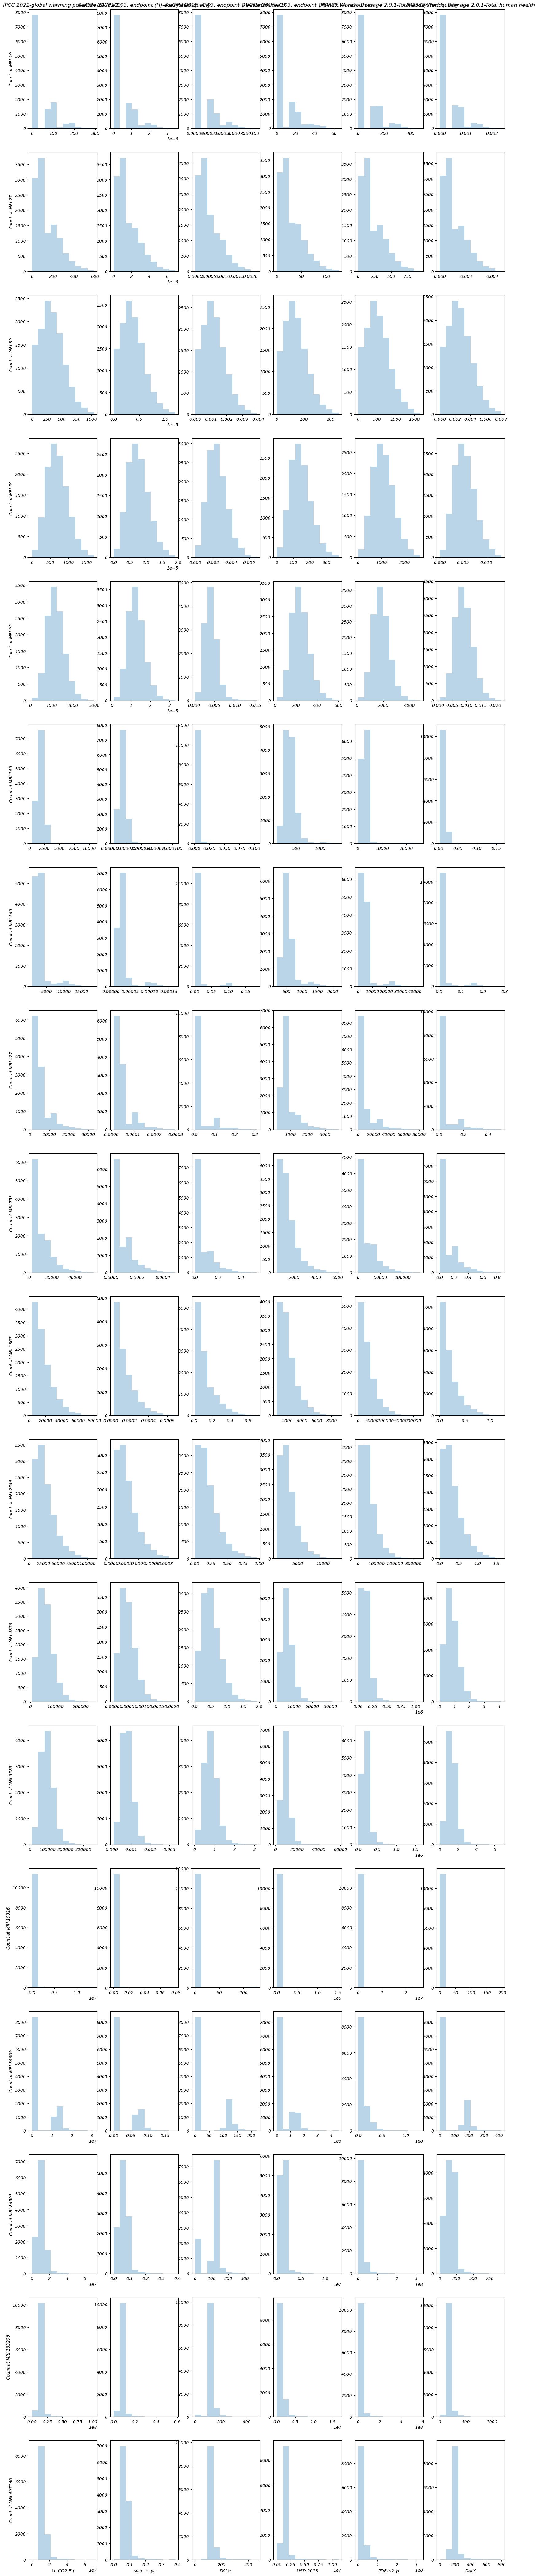

In [38]:
# Visual outputs
fig, axs = plt.subplots(len(ls_MRIs), len(LCIA_methods), figsize=(20, 6*len(ls_MRIs)))

for run_id,results in enumerate(cleansed_losses.keys()) :
    for val in range(len(LCIA_methods)) :
        
        arr = cleansed_losses[results][:,val]
        
        # Format the results
        _, bin_edges = np.histogram(arr,density = True)


        # Plot the results
        axs[run_id,val].hist(arr,bins = bin_edges,alpha = 0.3)  

        # Add figure descriptions :
        if run_id == 0 : 
            axs[run_id,val].set_title(f'{LCIA_methods[val][0]}-{LCIA_methods[val][2]}')
        if val == 0 :
            axs[run_id,val].set_ylabel(f'Count at MRI {results}')
        if run_id == len(cleansed_losses.keys())-1 : 
            axs[run_id,val].set_xlabel(bw.Method(LCIA_methods[val]).metadata['unit'])
        

check_outputs = True
if check_outputs == True : 
    with pd.ExcelWriter(f'MC_results.xlsx') as writer : 
        for run_id, results in enumerate(cleansed_losses.keys()):
            pd.DataFrame(cleansed_losses[results],columns = LCIA_methods).to_excel(writer,sheet_name=str(results),index=False)